In [1]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos, sin
from matplotlib.gridspec import GridSpec
import scipy.interpolate as sciint
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

In [2]:
project='realBathy'
ed='run7/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

if project=='realBathy':
    if ed == 'run7/' or ed == 'run5/' or ed == 'run4/':
        ds=xr.open_dataset(str(location) + 'dynDiagSmag3.nc')
    else:
        for i in np.arange(10,60,10):
            var='dynDiag'+str(i)
            if i==10:
                ds=xr.open_dataset(str(location) +  str(var) + '.nc')
            else:
                ds=ds.merge(xr.open_dataset(str(location) +  str(var) + '.nc'))
else:
    var='dynDiag'
    ds=xr.open_dataset(str(location) +  str(var) + '.nc')


#varS='surfDiag'

#dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(dsG.Y)
nx=len(dsG.X) 
nz=len(dsG.Z)
nt=len(ds.T) 

if project=='twoBumps':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)+1

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
if project=='realBathy':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)+1

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
else:
    umbral=np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0][int(len(np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0])/2)]
    umbralEnd=np.where(dsG.Depth[:,20]<np.max(dsG.Depth[:,20]))[0][-1]

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

#info=pd.read_csv(str(dataloc) + 'data',sep='/n')
#parameters=['viscAh','viscAr','diffKhT','diffKrT']


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='OpenNorth' or project =='Orlanski':
    OBp=1
    OBendp=-1
    OB=10
    OBend=-10
    OBx=1
    OBendx=-1
else:
    OBp=1
    OBendp=-1
    OB=20
    OBend=-20
    OBx=2
    OBendx=-2

In [3]:
project='realBathy'
ed='run5/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'
dsWVEL=xr.open_dataset(str(location) + 'vvel.nc')

In [32]:
Area=np.ma.masked_array(dsG.rA[umbralEnd1:umbralStart3,OBx:OBendx].values,mask=mask[depindUmb,umbralEnd1:umbralStart3,OBx:OBendx])
np.sum(Area*np.ma.masked_array(np.mean(dsWVEL.WVEL[:len(ds.T),depindUmb,umbralEnd1:umbralStart3,OBx:OBendx],axis=0),mask=mask[depindUmb,umbralEnd1:umbralStart3,OBx:OBendx])*1e-6)


np.float64(0.003828699972488493)

In [33]:
Area=np.ma.masked_array(dsG.rA[umbralEnd1:umbralStart3,OBx:OBendx].values,mask=mask[depindUmb,umbralEnd1:umbralStart3,OBx:OBendx])
np.sum(Area*np.ma.masked_array(np.mean(ds.WVEL[:,depindUmb,umbralEnd1:umbralStart3,OBx:OBendx],axis=0),mask=mask[depindUmb,umbralEnd1:umbralStart3,OBx:OBendx])*1e-6)


np.float64(0.006082717949362765)

In [4]:
params = {'font.size': 10,
          'figure.figsize': (7.48, 5),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

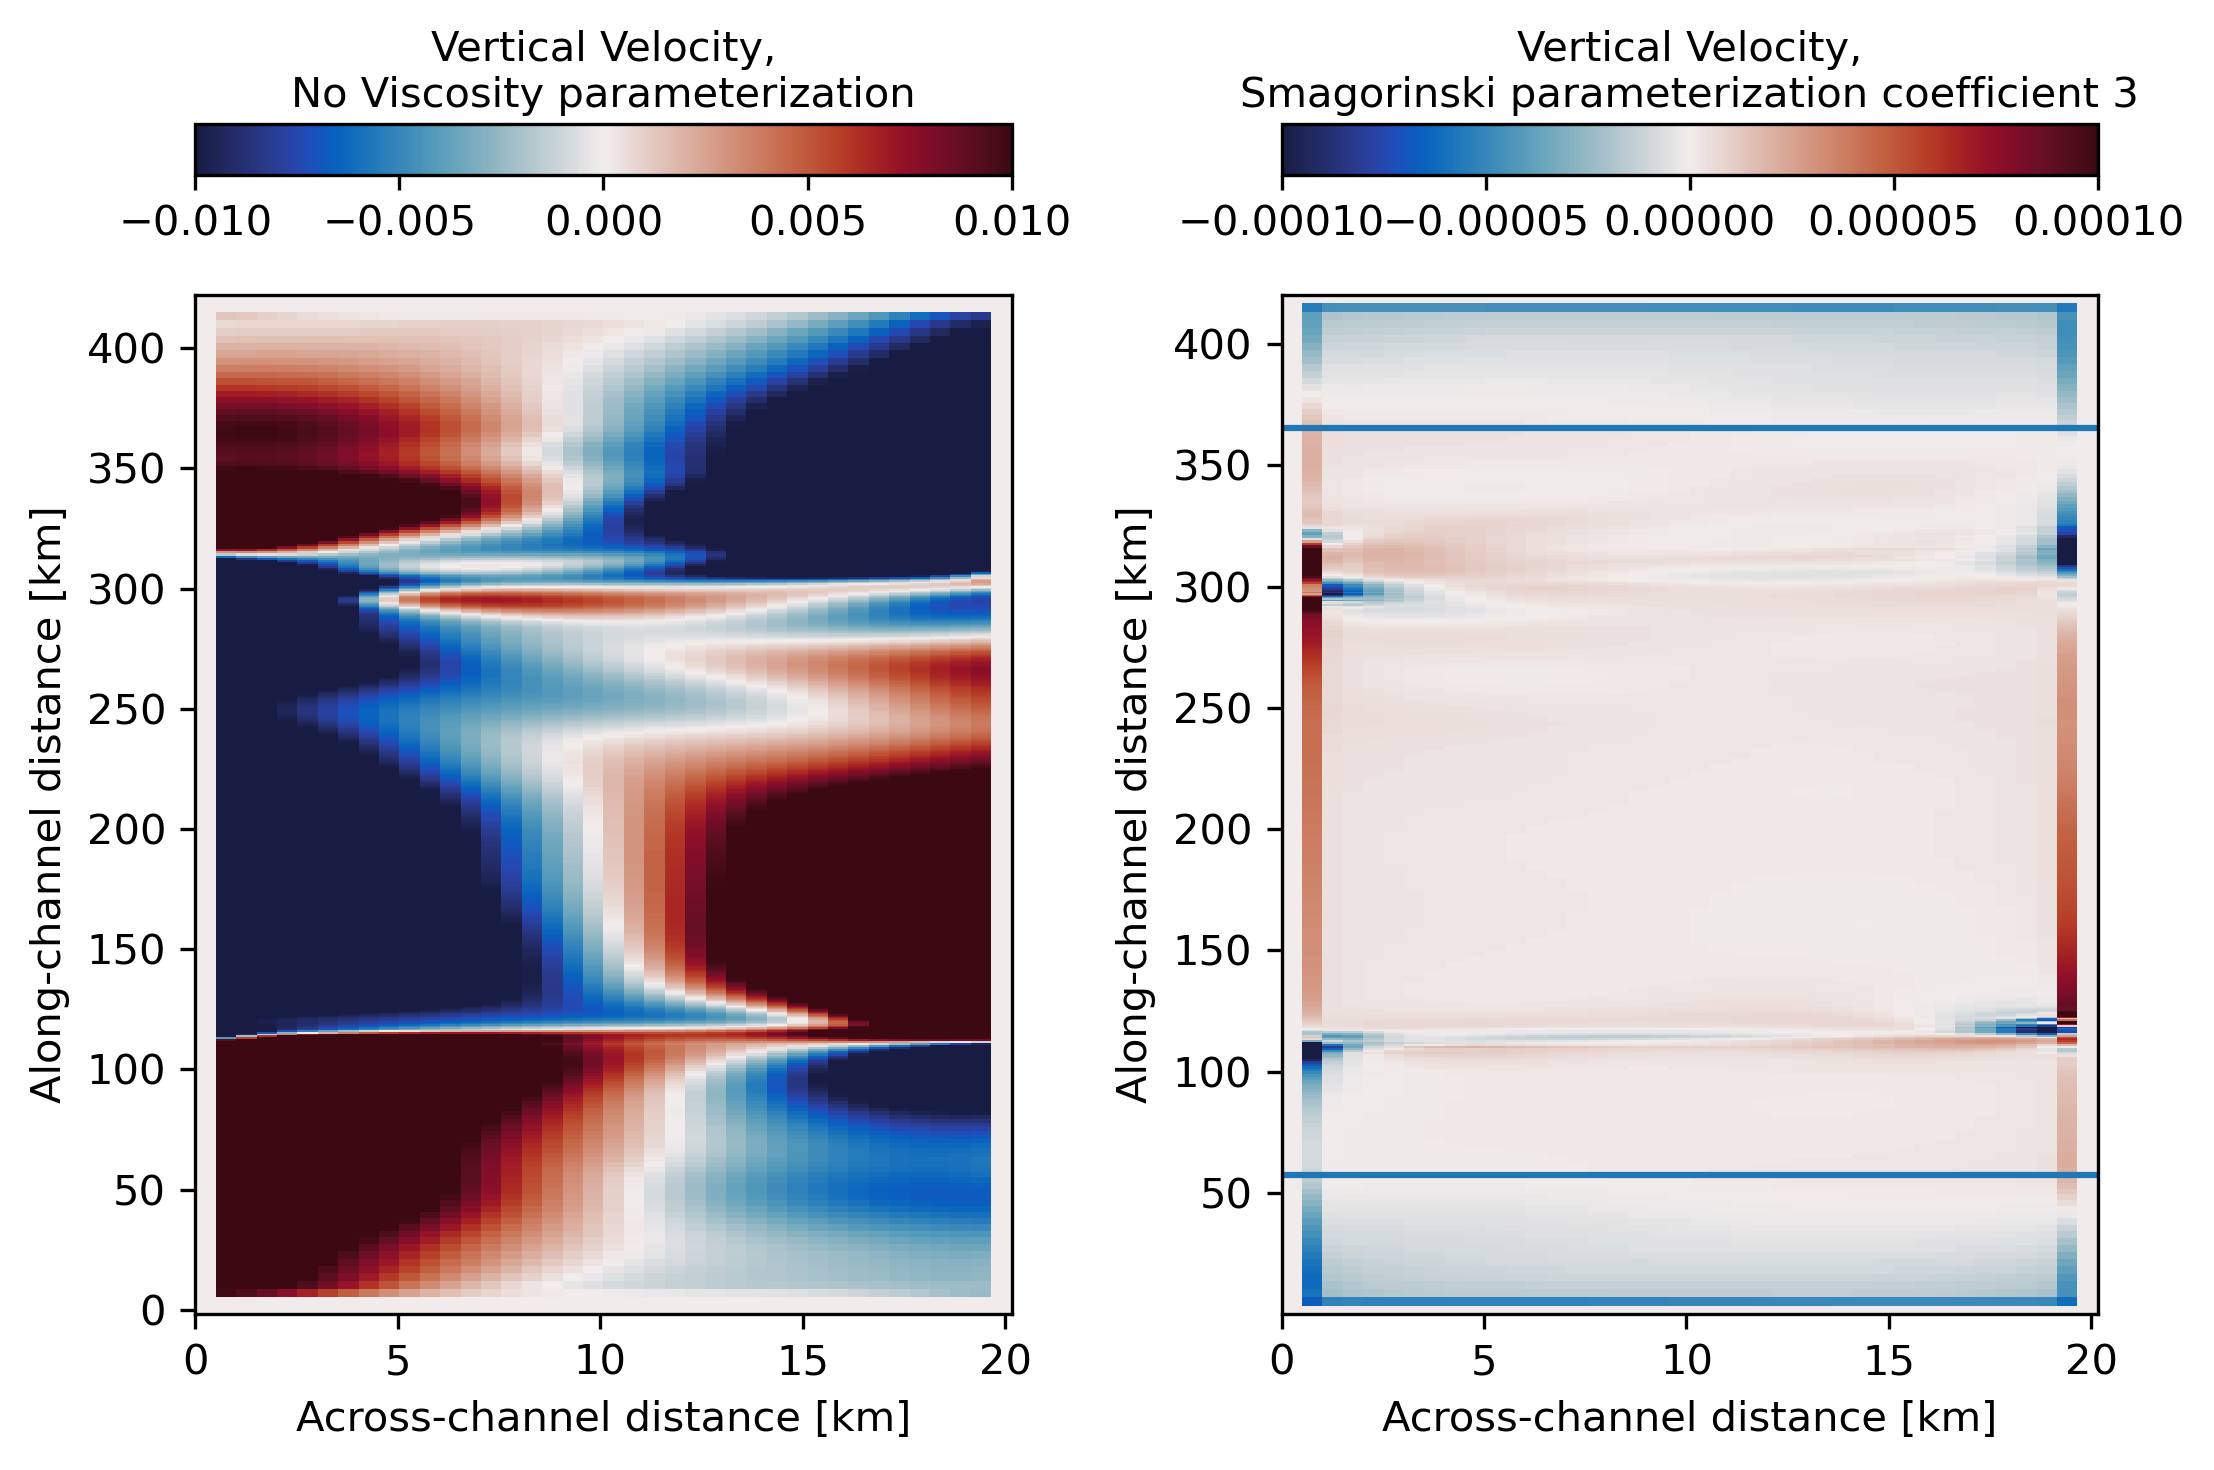

In [5]:
fig,ax=plt.subplots(1,2)
cax=ax[0].pcolormesh(dsG.X/1000,dsG.Yp1/1000,ds.VVEL[-1,26,:,:],vmin=-0.01,vmax=0.01,cmap=cmocean.cm.balance)

divider = make_axes_locatable(ax[0])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nNo Viscosity parameterization')

cax1=ax[1].pcolormesh(dsG.X/1000,dsG.Y/1000,ds.WVEL[-1,26,:,:],vmin=-0.0001,vmax=0.0001,cmap=cmocean.cm.balance)

ax[1].axhline(dsG.Y[20]/1000)
ax[1].axhline(dsG.Y[-20]/1000)

divider = make_axes_locatable(ax[1])
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax1, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label('Vertical Velocity,\nSmagorinski parameterization coefficient 3')



ax[0].set(xlabel='Across-channel distance [km]',ylabel='Along-channel distance [km]')
ax[1].set(xlabel='Across-channel distance [km]',ylabel='Along-channel distance [km]')
fig.tight_layout()

In [3]:
start=np.where(ds.T/(60*60*24*360)>=1)[0][0]
end =np.where(ds.T/(60*60*24*360)<=60)[0][-1] # np.where(np.isnan(ds.WVEL[:,10,10,5])==False)[0][-1] #

In [6]:
umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
umbral2=np.where(dsG.Depth[int(ny/2):-int(ny/4),20].values==np.min(dsG.Depth[int(ny/2):-int(ny/4),20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):-int(ny/4),20].values==600)[0])/2)]+int(ny/2)+1
umbral3=np.where(dsG.Depth[-int(ny/4):,20].values==np.min(dsG.Depth[-int(ny/4):,20].values))[0][-1]+(len(dsG.Depth[:,0])-int(ny/4))-7


umbralEnd1=np.where(dsG.Depth[:int(ny/3),20]<np.max(dsG.Depth[:int(ny/3),20]))[0][-1]+1
umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)

In [7]:
depindUmb=np.where(dsG.Z>=-np.min(dsG.Depth.values[dsG.Depth.values!=0]))[0][-1]+1
depind800=np.where(dsG.Z<-600)[0][0]-1
umbralStart2=np.where(dsG.Depth[umbralEnd1:,20]<np.max(dsG.Depth))[0][0]+umbralEnd1
umbralStart3=np.where(dsG.Depth[umbral2:umbral3,20]==np.max(np.max(dsG.Depth[umbral2:umbral3,20])))[0][0]+umbral2


In [46]:
umbralStart3

np.int64(371)

In [39]:
np.max(np.max(dsG.Depth[umbral2:umbral3,20]))

<xarray.DataArray 'Depth' ()> Size: 8B
array(806.18548584)
Coordinates:
    X        float64 8B 1.033e+04

In [41]:
params = {'font.size': 10,
          'figure.figsize': (12, 5),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [42]:
project='realBathy'
ed='run7/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'
dsWVEL=xr.open_dataset(str(location) + 'wvel.nc')
dsVVEL=xr.open_dataset(str(location) + 'vvel.nc')

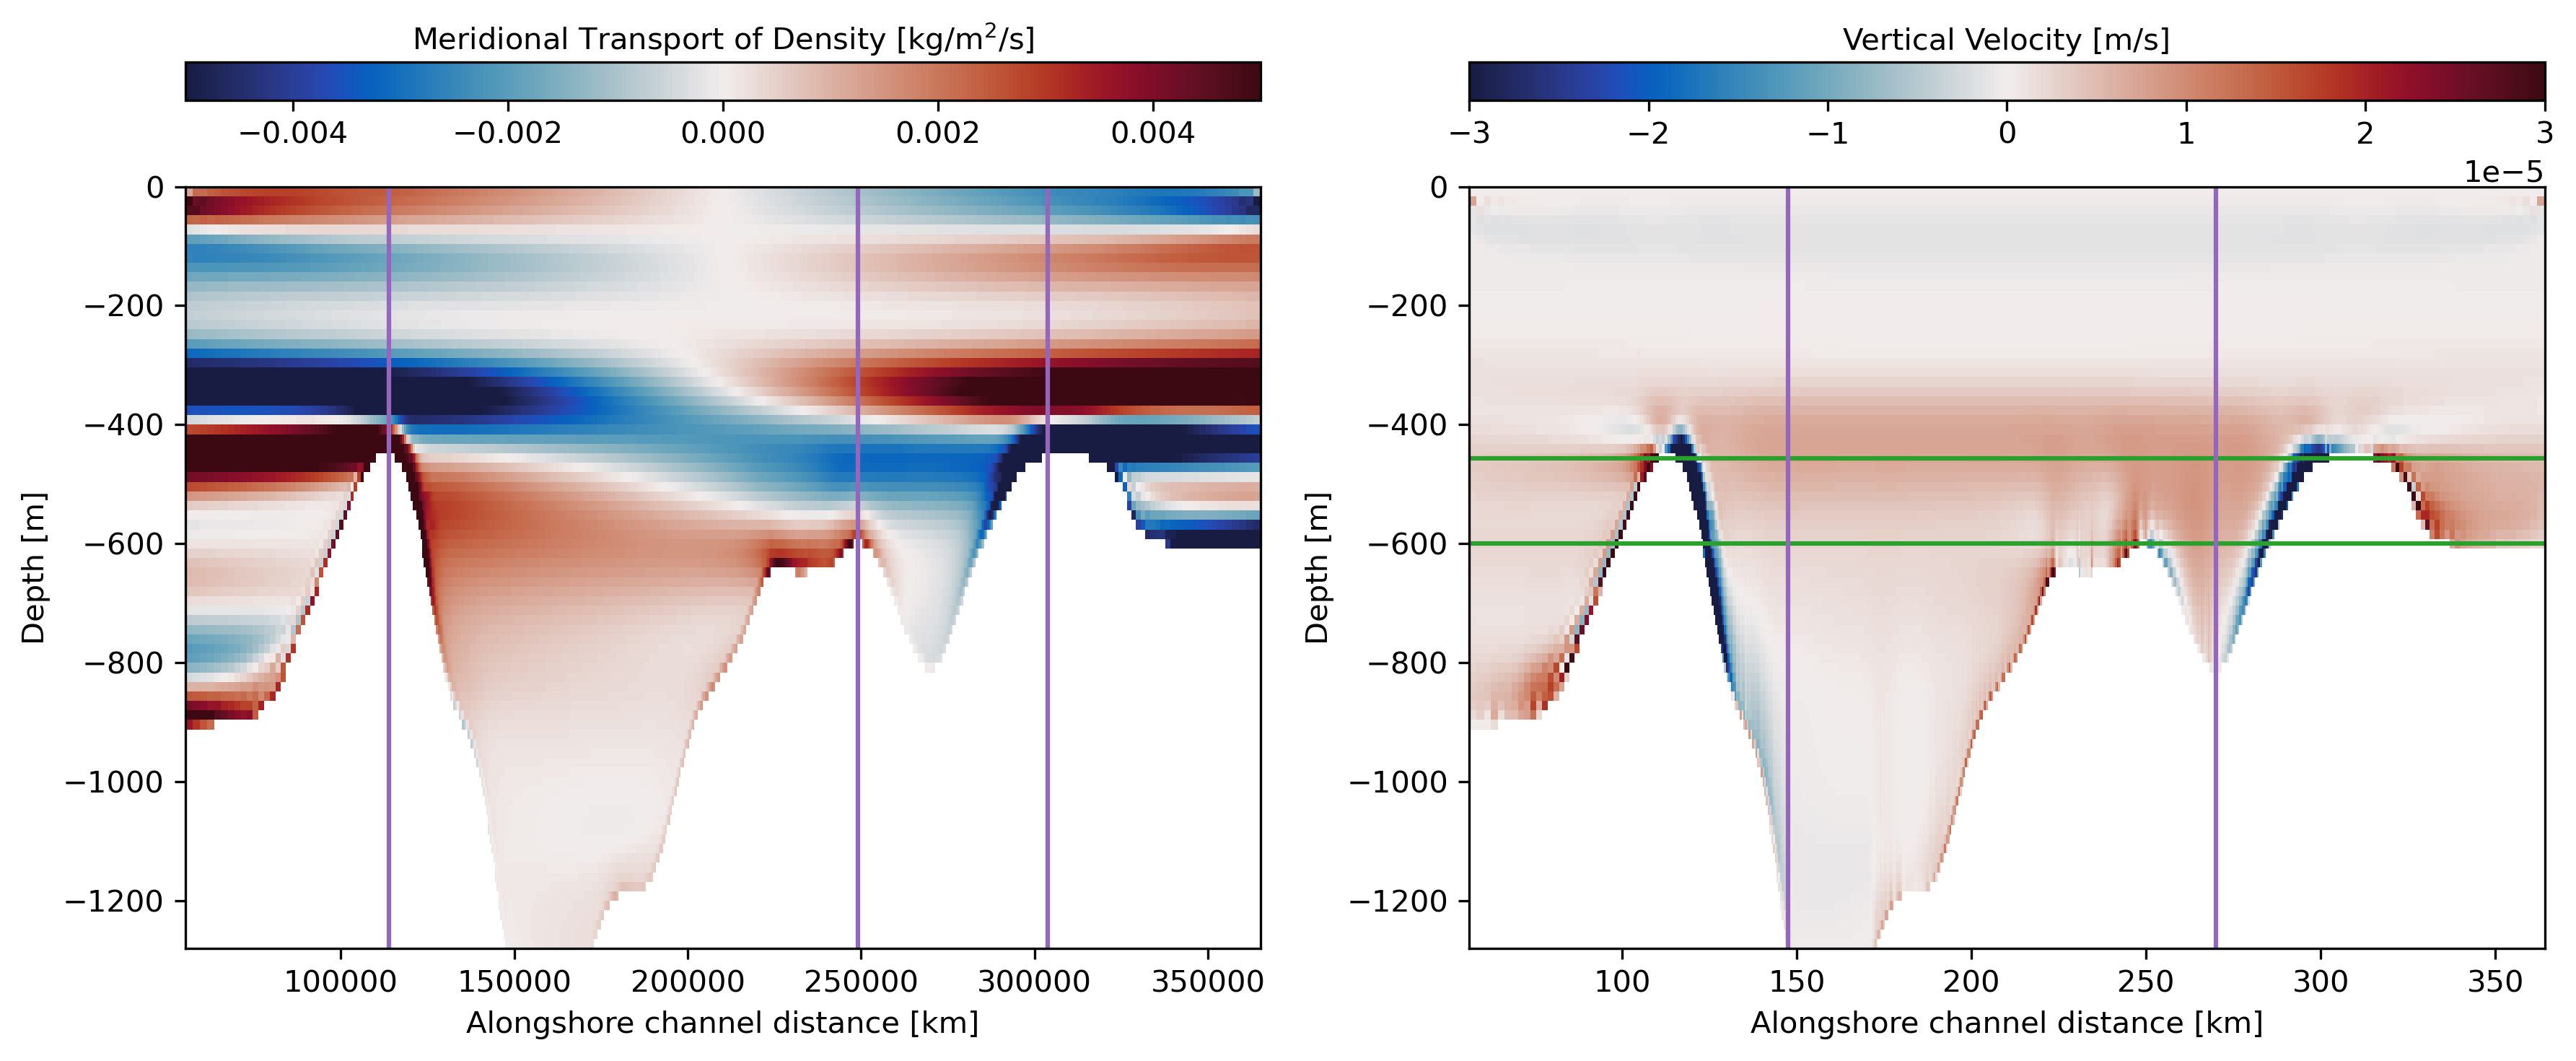

In [43]:
fig,axin=plt.subplots(1,2)
ax=axin[0]
title='Meridional Transport of Density [kg/m$^2$/s]'
cax= ax.pcolormesh(dsG.Yp1[OB:OBend],dsG.Z,np.mean(np.ma.masked_array(np.mean(dsVVEL.VVEL[:,:,OB:OBend,OBx:OBendx],axis=0),mask=masks[:,OB:OBend,OBx:OBendx]),axis=2),vmin=-0.005,vmax=0.005,cmap=cmocean.cm.balance)
ax.axvline(dsG.Yp1[umbral1],color='tab:purple')
ax.axvline(dsG.Yp1[umbral2],color='tab:purple')
ax.axvline(dsG.Yp1[umbral3],color='tab:purple')

divider = make_axes_locatable(ax)
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)
ax.set(xlabel='Alongshore channel distance [km]',ylabel='Depth [m]')

ax=axin[1]
title='Vertical Velocity [m/s]'
cax= ax.pcolormesh(dsG.Y[OB:OBend]/1000,dsG.Z,np.mean(np.ma.masked_array(np.mean(dsWVEL.WVEL[:,:,OB:OBend,OBx:OBendx].values,axis=0),mask=mask[:,OB:OBend,OBx:OBendx]),axis=2),vmin=-0.00003,vmax=0.00003,cmap=cmocean.cm.balance)
ax.axhline(dsG.Z[depindUmb],color='tab:green')
ax.axhline(dsG.Z[depind800],color='tab:green')

ax.axvline(dsG.Y[umbralEnd1]/1000,color='tab:purple')
#ax.axvline(dsG.Y[umbralStart2]/1000,color='tab:purple')
ax.axvline(dsG.Y[umbralStart3]/1000,color='tab:purple')

#for i in np.arange(depindUmb,len(dsG.Z),int((len(dsG.Z)-depindUmb)/5)):
 #   ax.axhline(dsG.Z[i],color='k',linewidth=0.7)


divider = make_axes_locatable(ax)
axdiv = divider.new_vertical(size = '5%', pad = 0.4)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)
ax.set(xlabel='Alongshore channel distance [km]',ylabel='Depth [m]')
fig.tight_layout()
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'AlongChannelTransport.png', bbox_inches='tight')

In [21]:
OBx=1
OBendx=-1

In [58]:
transpDepths=[]

for i in np.arange(depindUmb,len(dsG.Z),1):
    Area=np.ma.masked_array(dsG.rA[umbral1:umbral3,OBx:OBendx].values,mask=mask[i,umbral1:umbral3,OBx:OBendx])
    transpDepths.append(Area*np.ma.masked_array(np.mean(dsWVEL.WVEL[-2:,i,umbral1:umbral3,OBx:OBendx],axis=0),mask=mask[i,umbral1:umbral3,OBx:OBendx])*1e-6)



In [20]:
OBx

2

In [59]:
outtranspInt=[]
for k in range(len(transpDepths)):
    integratTransp=np.zeros(len(transpDepths[k][:,0]))
    for i in range(len(transpDepths[k][:,0])):
        integratTransp[i]= np.sum(transpDepths[k][i,:])#np.trapezoid(transpDepths[k][i,:], dx=504)
    outtranspInt.append(integratTransp)   

/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_8136/3147073563.py:5: UserWarning: Warning: converting a masked element to nan.
  integratTransp[i]= np.sum(transpDepths[k][i,:])#np.trapezoid(transpDepths[k][i,:], dx=504)


In [60]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

In [122]:
transp1Sill=np.zeros((len(outtranspInt),50))
transp3Sill=np.zeros((len(outtranspInt),50))
for k in range(len(outtranspInt)):
    ind1Sill=np.where(outtranspInt[k]>0)[0][0]
    ind3Sill=np.where(outtranspInt[k]>0)[0][-1]
    transpIN=outtranspInt[k][:ind1Sill]
    transpIN3=outtranspInt[k][ind3Sill:]
    
    transp1Sill[k,:len(transpIN[np.where(np.isnan(transpIN)==False)])]=transpIN[np.where(np.isnan(transpIN)==False)]
    transp3Sill[k,:len(transpIN3[np.where(np.isnan(transpIN3)==False)])]=transpIN3[np.where(np.isnan(transpIN3)==False)]


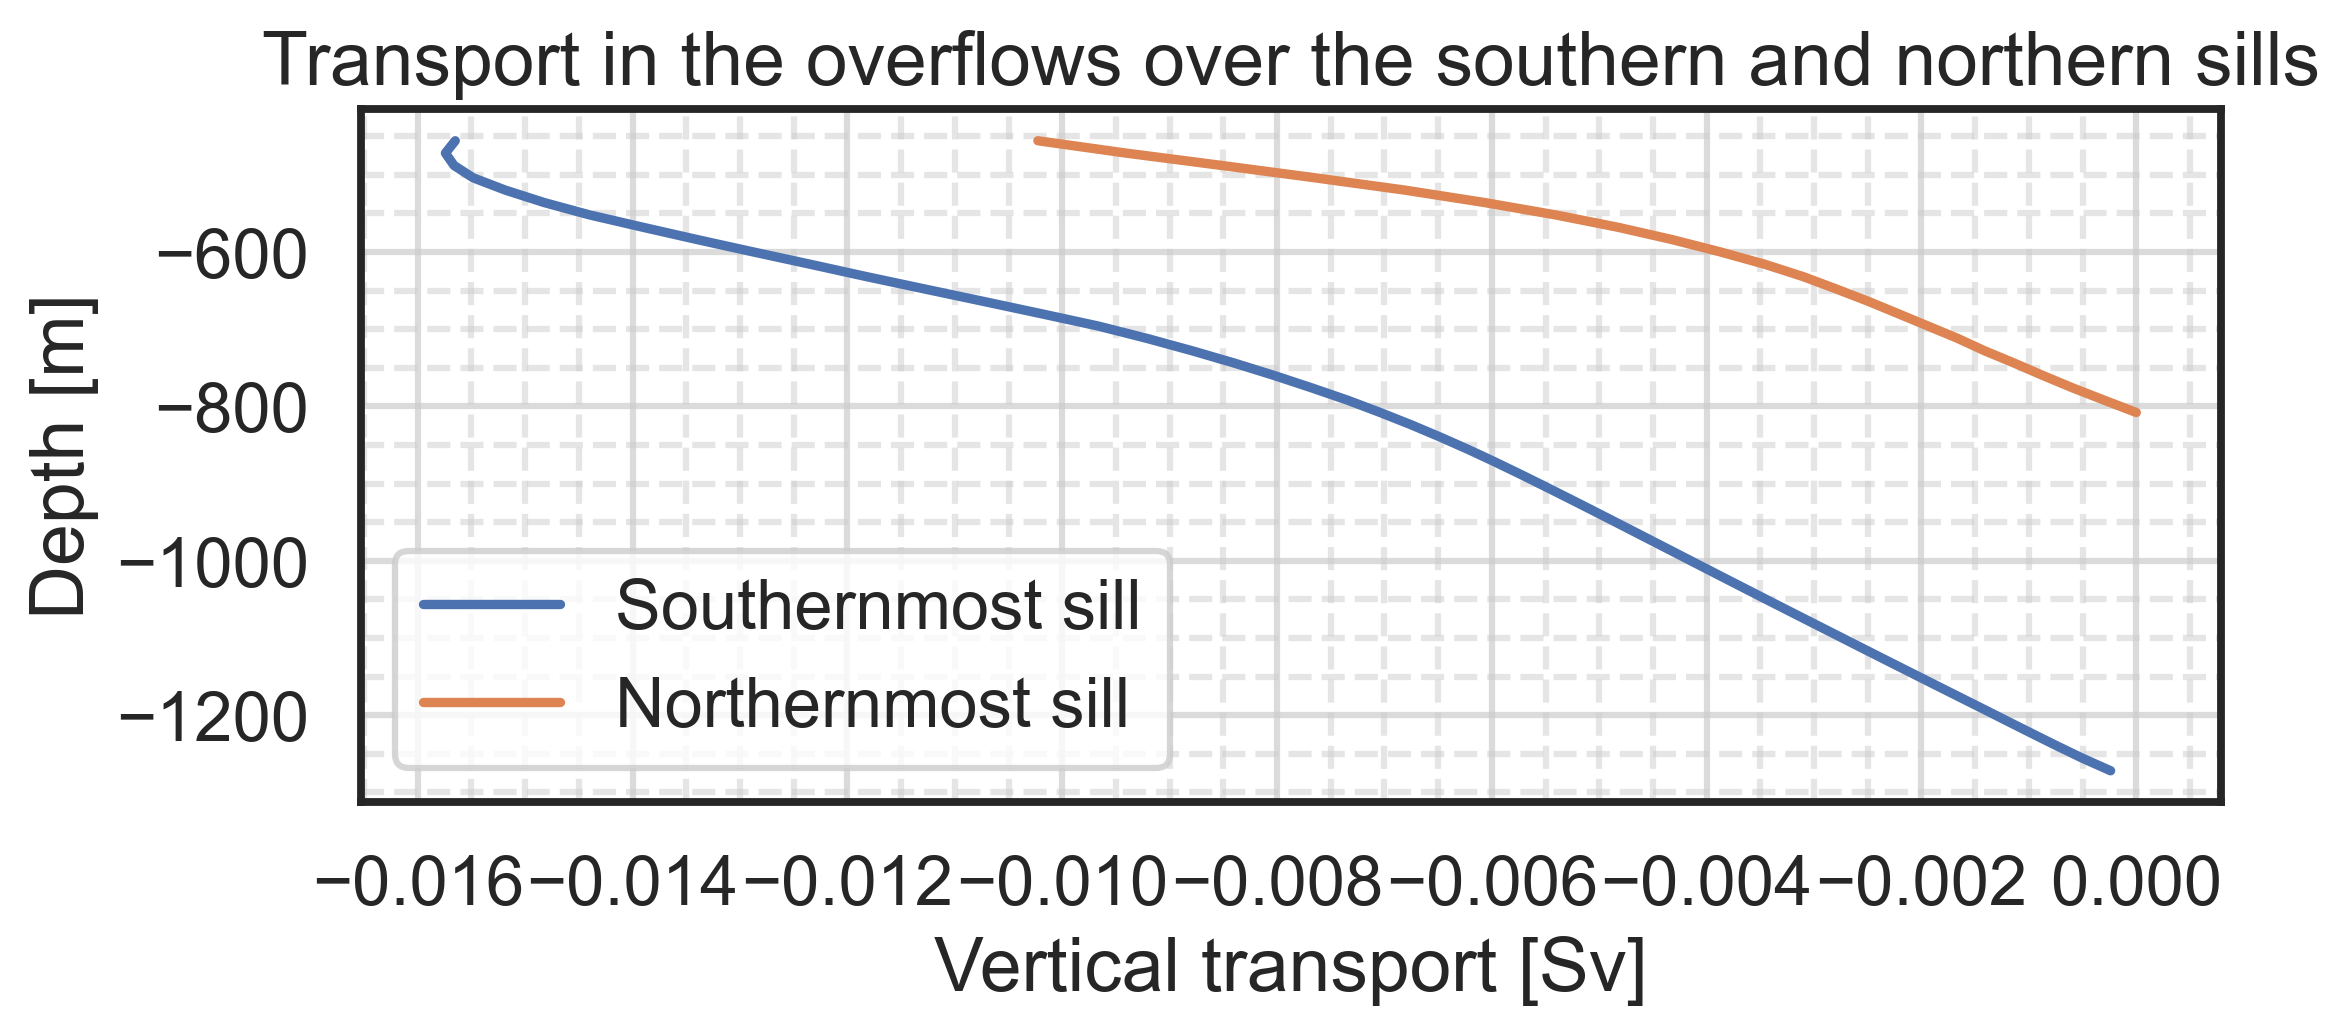

In [136]:
plt.plot(np.sum(transp1Sill,axis=1),dsG.Z[depindUmb:],label='Southernmost sill')
plt.plot(np.sum(transp3Sill[:-29],axis=1),dsG.Z[depindUmb:-29],label='Northernmost sill')

plt.minorticks_on()
plt.xlabel('Vertical transport [Sv]')
plt.ylabel('Depth [m]')
plt.title('Transport in the overflows over the southern and northern sills')
plt.grid(which='minor',linestyle='--', alpha=0.5)
plt.grid(which='major',alpha=0.7)
plt.legend()
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'TranspOverflows.png', bbox_inches='tight')

In [62]:
params = {'font.size': 10,
          'figure.figsize': (8, 3),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

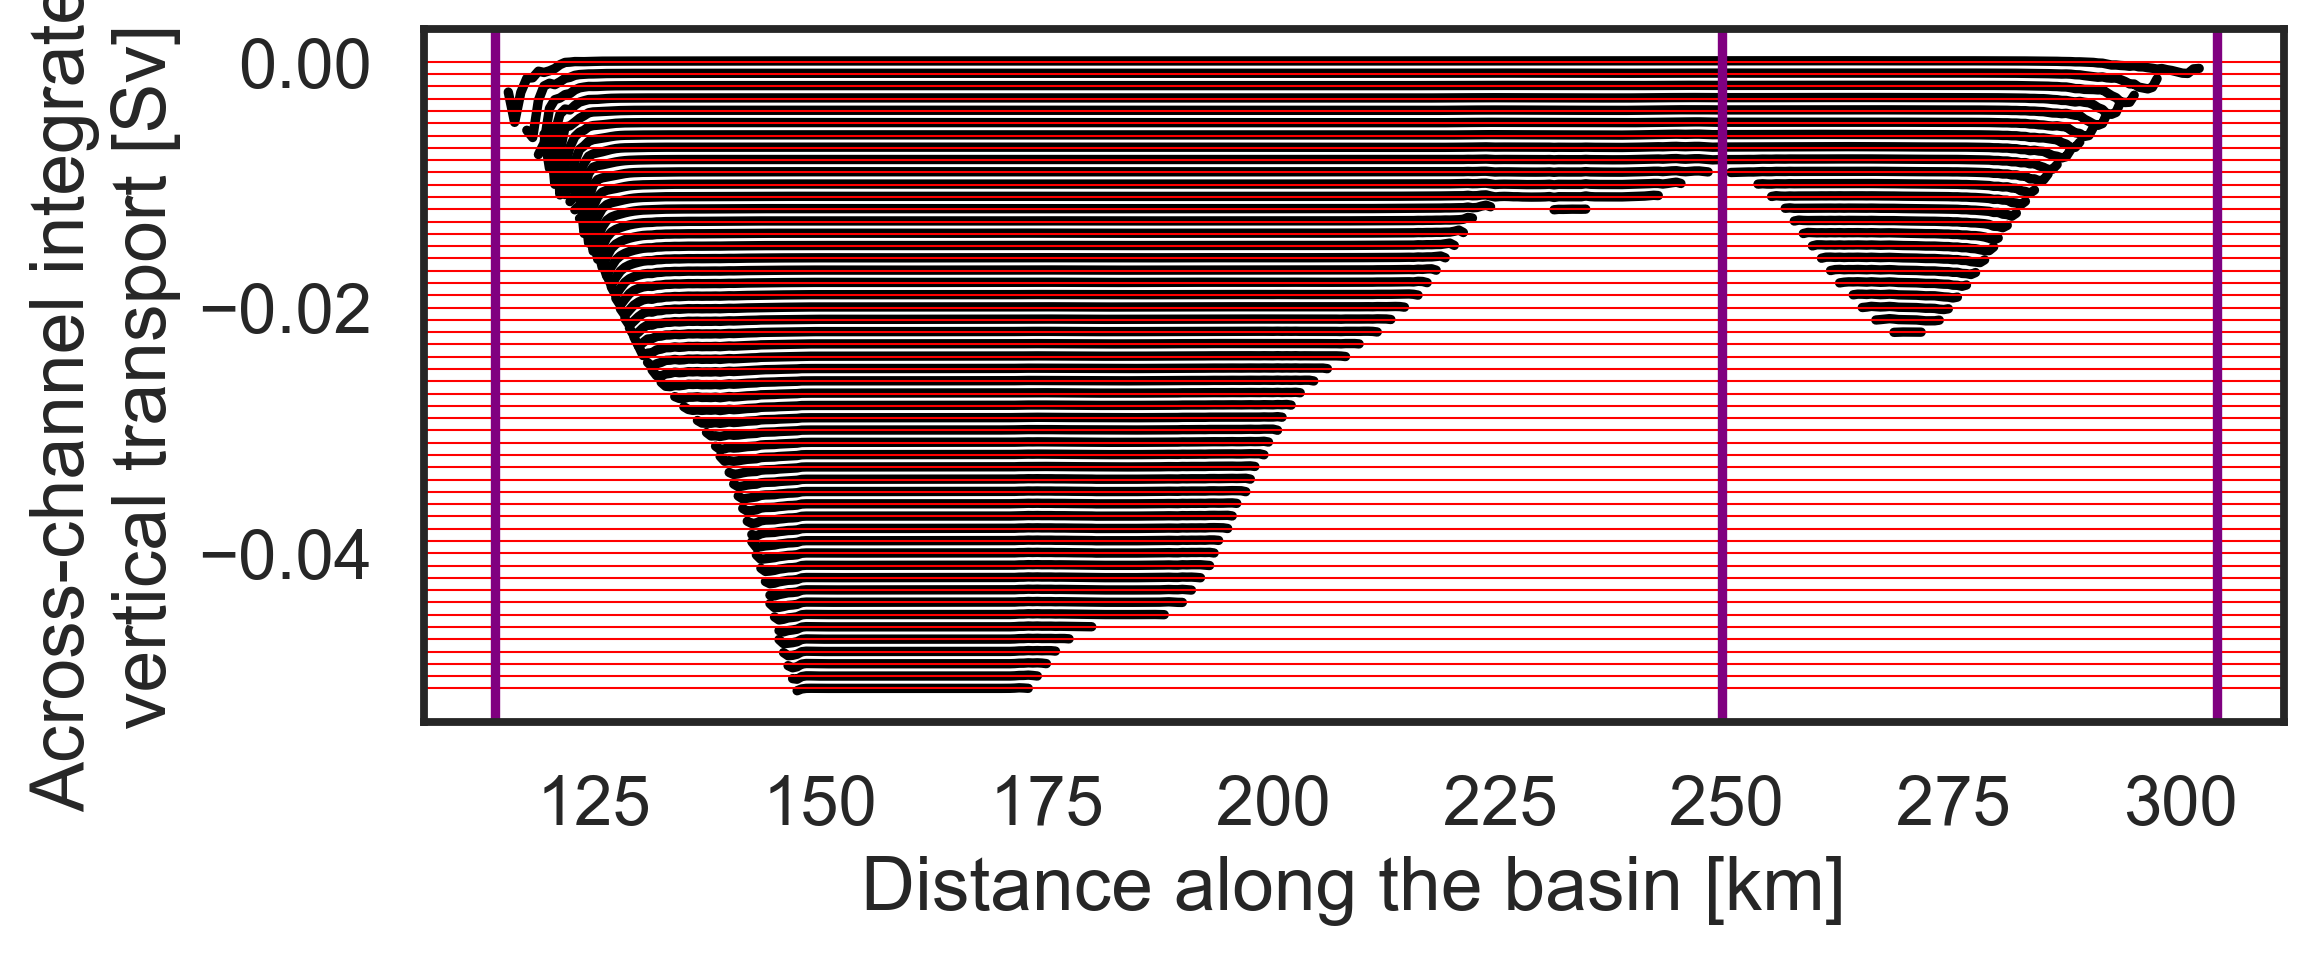

In [63]:
fig,ax=plt.subplots()
for k in range(len(transpDepths)):
    ax.plot(dsG.Y[umbral1:umbral3]/1000,outtranspInt[k]-0.001*k,color='black')
    ax.axhline(0-0.001*k,linewidth=0.5,color='red')

#ax.set_ylim((-0.7,0.2))
ax.set_xlabel('Distance along the basin [km]')
ax.set_ylabel('Across-channel integrated\nvertical transport [Sv]')
ax.axvline(dsG.Y[umbral1]/1000,color='Purple')
ax.axvline(dsG.Y[umbral2]/1000,color='Purple')
ax.axvline(dsG.Y[umbral3]/1000,color='Purple')
'''
axins = zoomed_inset_axes(ax, 3, loc='upper right',
                   bbox_to_anchor=(0.9, 0.7),
                   bbox_transform=ax.transAxes)

for k in range(len(transpDepths)):
    axins.plot(dsG.Y[umbral1:umbral3]/1000,outtranspInt[k]-0.1*k,color='black')
    axins.axhline(0-0.1*k,linewidth=0.5,color='red')

# sub region of the original image
x1, x2, y1, y2 = 135, 180, -0.6, -0.35
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

plt.xticks(visible=False)
plt.yticks(visible=False)

# draw a bbox of the region of the inset axes in the parent axes and
# connecting lines between the bbox and the inset axes area
mark_inset(ax, axins, loc1=1, loc2=1, fc="none", ec="0.1")
'''
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'TranspVertIntX.png', bbox_inches='tight')

## Vertical transport

In [45]:
project='realBathy'
ed='run7/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'
ds=xr.open_dataset(str(location) + 'wvel.nc')


In [46]:
OBx=1
OBendx=-1
Area=np.ma.masked_array(dsG.rA[umbral1:umbral3,OBx:OBendx].values,mask=mask[depindUmb,umbral1:umbral3,OBx:OBendx])
#transpDens1=np.sum(Area*np.ma.masked_array(np.mean(ds.WRHOMASS[-2:,depindUmb,umbral1:umbral3,OBx:OBendx],axis=0),mask=mask[depindUmb,umbral1:umbral3,OBx:OBendx]))
transpSv1=Area*np.ma.masked_array(np.mean(ds.WVEL[-2:,depindUmb,umbral1:umbral3,OBx:OBendx],axis=0),mask=mask[depindUmb,umbral1:umbral3,OBx:OBendx])*1e-6

#print(f'Total upwelling transport after first sill at depth 600 m {transpSv1:.3f} kg/s or {np.sum(transpSv1):.3f} Sv')



In [47]:
Area=np.ma.masked_array(dsG.rA[umbralEnd1:umbralStart3,OBx:OBendx].values,mask=mask[depindUmb,umbralEnd1:umbralStart3,OBx:OBendx])
#transpDens2=np.sum(Area*np.ma.masked_array(np.mean(ds.WRHOMASS[:,depindUmb,umbralEnd1:umbralStart3,OBx:OBendx],axis=0),mask=mask[depindUmb,umbralEnd1:umbralStart3,OBx:OBendx]))
transpSv2=Area*np.ma.masked_array(np.mean(ds.WVEL[-2:,depindUmb,umbralEnd1:umbralStart3,OBx:OBendx],axis=0),mask=mask[depindUmb,umbralEnd1:umbralStart3,OBx:OBendx])*1e-6

#print(f'Total upwelling transport after first sill at depth 600 m {transpDens2:.3f} kg/m^2/s or {np.sum(transpSv2):.3f} Sv')



In [48]:
Area=dsG.rA[umbral1:umbral3,OBx:OBendx].values*dsG.HFacC[depind800,umbral1:umbral3,OBx:OBendx].values
#transpDens3=np.sum(Area*np.ma.masked_array(np.mean(ds.WRHOMASS[:,depind800,umbral1:umbral3,OBx:OBendx],axis=0),mask=mask[depind800,umbral1:umbral3,OBx:OBendx]))
transpSv3=Area*np.ma.masked_array(np.mean(ds.WVEL[-2:,depind800,umbral1:umbral3,OBx:OBendx],axis=0),mask=mask[depind800,umbral1:umbral3,OBx:OBendx])*1e-6

#print(f'Total upwelling transport after first sill at depth 800 m {transpDens3:.3f}  kg/m^2/s or {np.sum(transpSv3):.3f} Sv')



In [49]:
Area=dsG.rA[umbralEnd1:umbralStart3,OBx:OBendx].values*dsG.HFacC[depind800,umbralEnd1:umbralStart3,OBx:OBendx].values
transpSv4=Area*np.ma.masked_array(np.mean(ds.WVEL[-2:,depind800,umbralEnd1:umbralStart3,OBx:OBendx],axis=0),mask=mask[depind800,umbralEnd1:umbralStart3,OBx:OBendx])*1e-6
#transpDens4=np.sum(Area*np.ma.masked_array(np.mean(ds.WRHOMASS[:,depind800,umbralEnd1:umbralStart3,OBx:OBendx],axis=0),mask=mask[depind800,umbralEnd1:umbralStart3,OBx:OBendx]))
#print(f'Total upwelling transport between topography at depth 800 m {transpDens4:.3f}  kg/m^2/s or {np.sum(transpSv4):.3f} Sv')



In [50]:
params = {'font.size': 12,
          'figure.figsize': (7.48, 12),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [51]:
sns.set_theme(context="talk",style='white')

/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_8136/1237400082.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


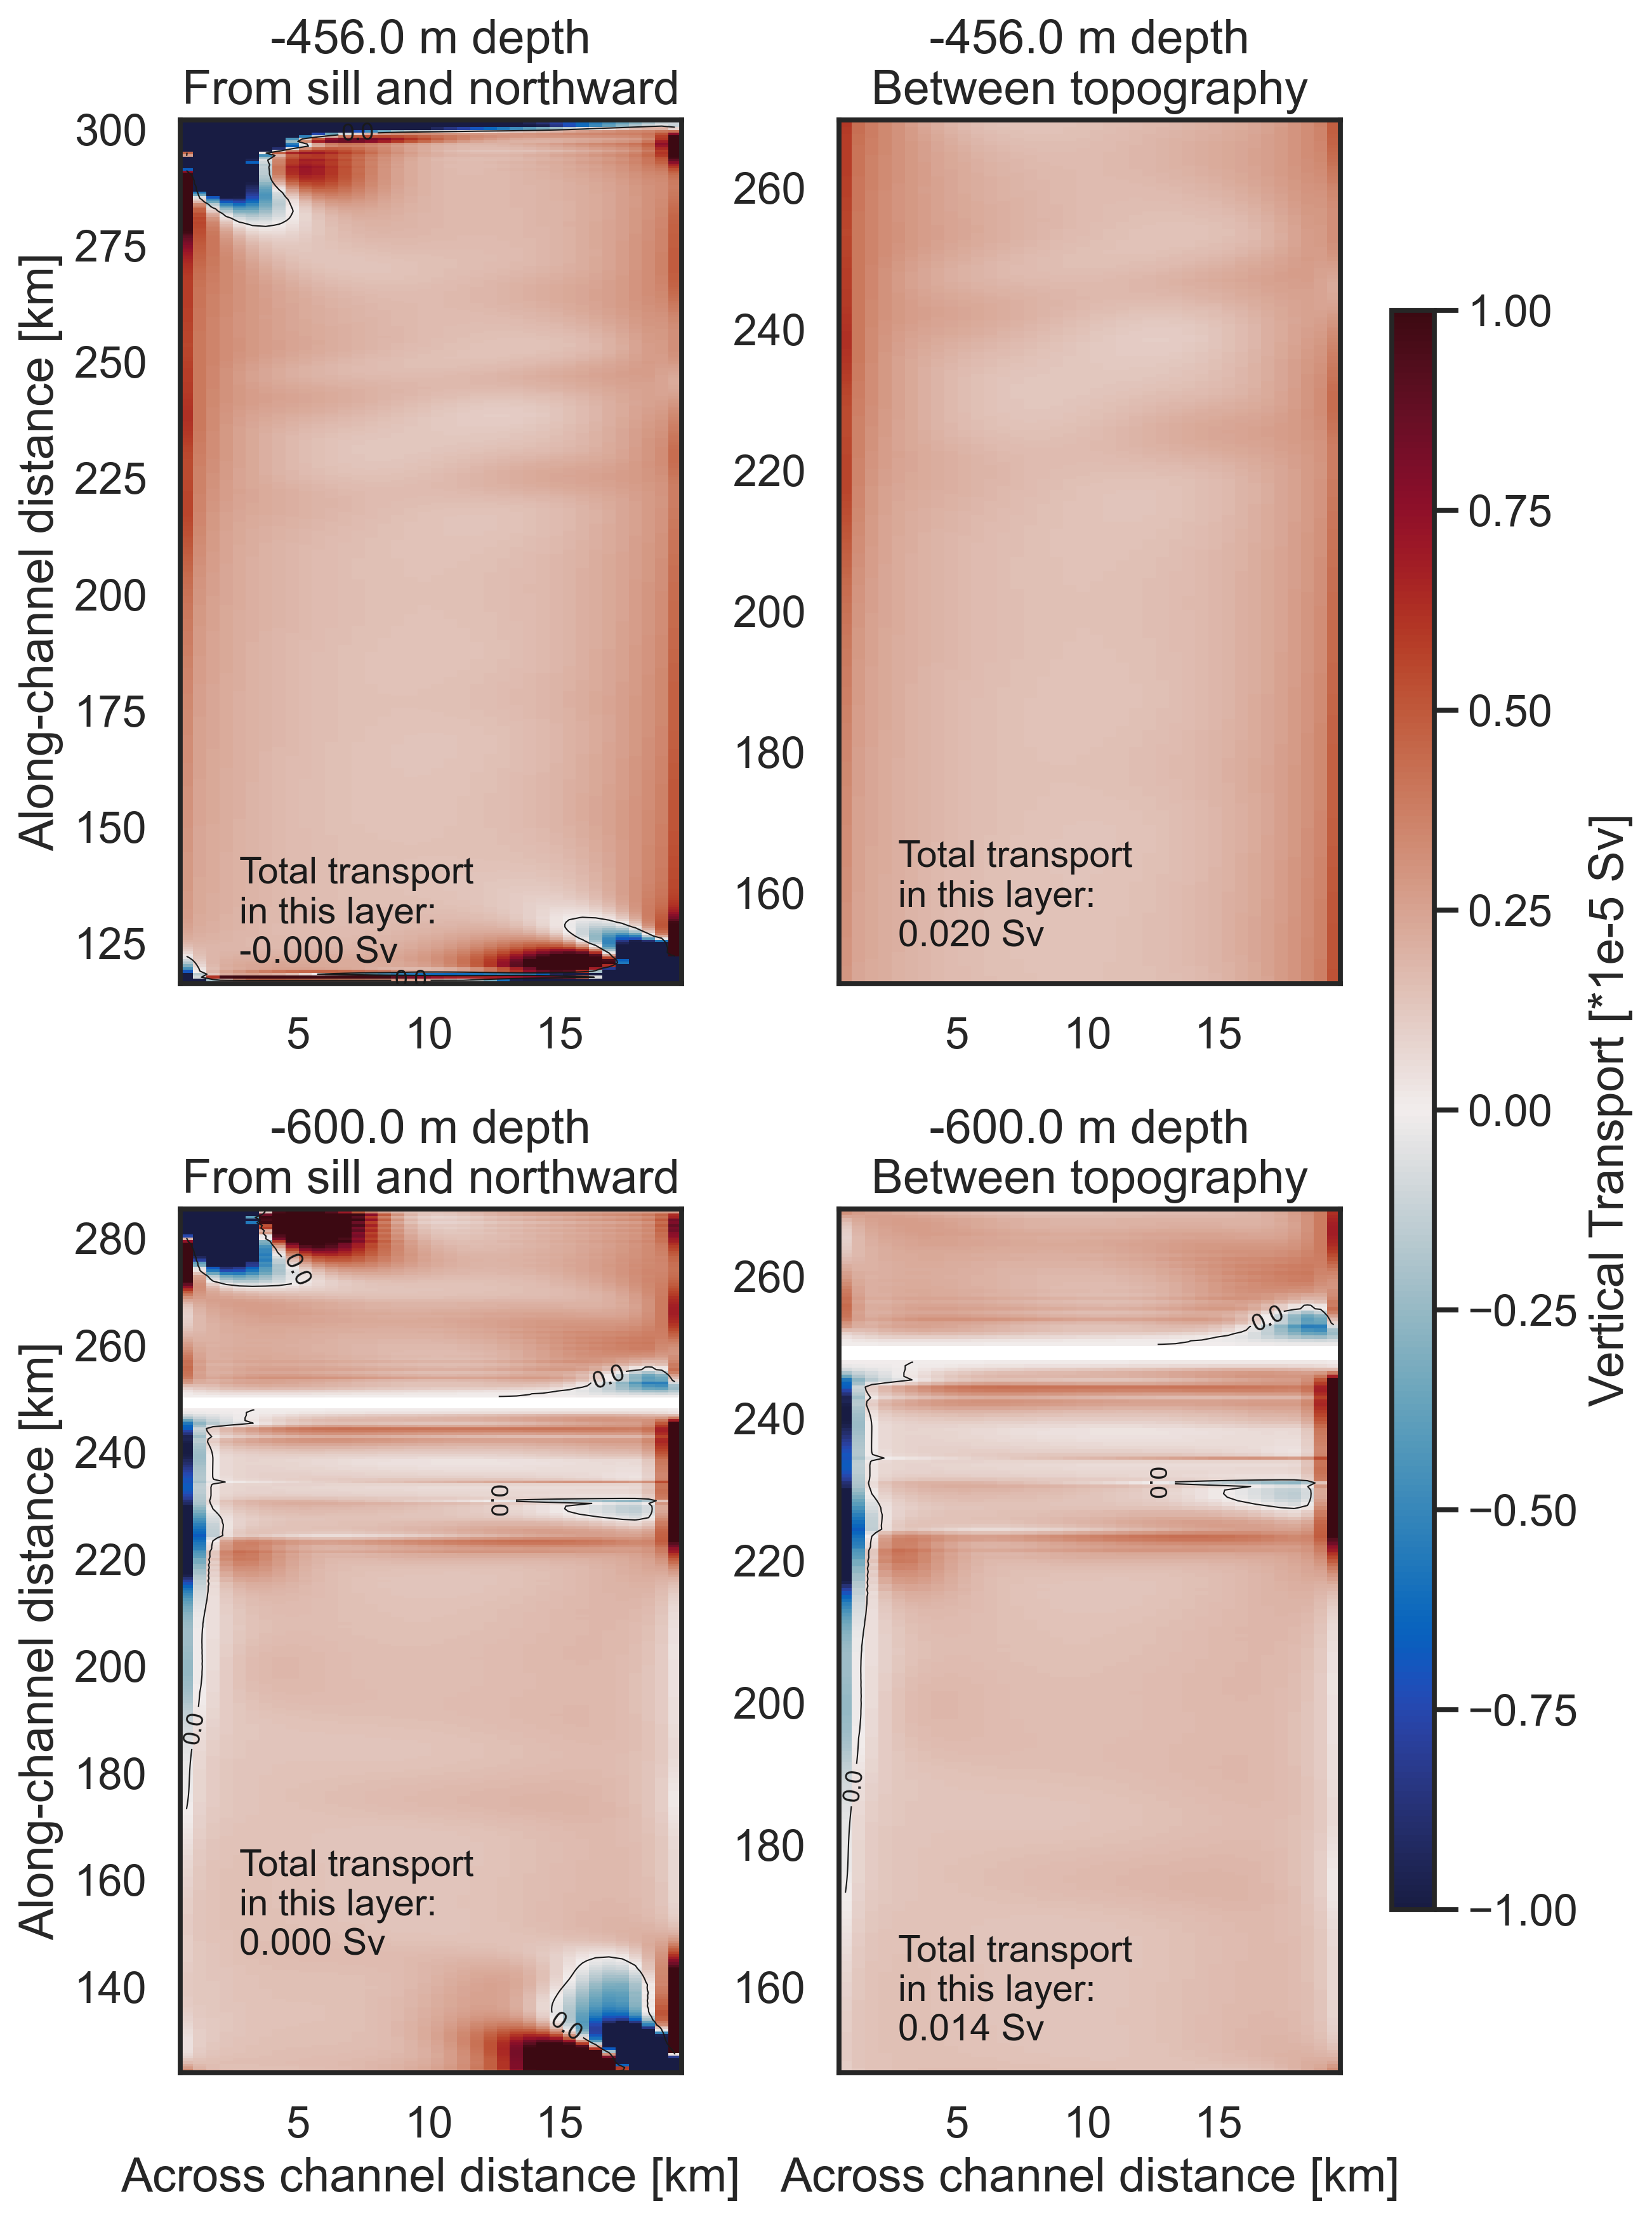

In [52]:
indy=np.arange(umbral1,umbralEnd1,1)
p=0 #np.arange(0,50,10)[0]
start=-2
vmin=-1
vmax=1
fig,axin=plt.subplots(2,2)
ax=axin[0,0]
cax=ax.pcolormesh(dsG.X[OBx:OBendx]/1000,dsG.Y[umbral1:umbral3]/1000,transpSv1*1e5,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)
ax.set(ylabel='Along-channel distance [km]',title=f'{dsG.Z[depindUmb].values:.1f} m depth\nFrom sill and northward')

ax.text(dsG.X[5]/1000,dsG.Y[umbral1+10]/1000,  f'Total transport\nin this layer:\n{np.sum(transpSv1):.3f} Sv', color='k',fontsize=14)

ymax=dsG.Y[umbral1:umbral3].values[mask[depindUmb,umbral1:umbral3,5]==False][-1]
ymin=dsG.Y[umbral1:umbral3].values[mask[depindUmb,umbral1:umbral3,5]==False][1]
ax.set_ylim((ymin/1000,ymax/1000))

caxC=ax.contour(dsG.X[OBx:OBendx]/1000,dsG.Y[umbral1:umbral3]/1000,transpSv1*1e5,levels=[0],colors='k',linewidths=0.5)
ax.clabel(caxC, inline=1, fmt='%1.1f',fontsize=9)

ax=axin[0,1]
cax=ax.pcolormesh(dsG.X[OBx:OBendx]/1000,dsG.Y[umbralEnd1:umbralStart3]/1000,transpSv2*1e5,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)


ax.set(title=f'{dsG.Z[depindUmb].values:.1f} m depth\nBetween topography')

ax.text(dsG.X[5]/1000, dsG.Y[umbralEnd1+10]/1000, f'Total transport\nin this layer:\n{np.sum(transpSv2):.3f} Sv', color='k',fontsize=14)

caxC=ax.contour(dsG.X[OBx:OBendx]/1000,dsG.Y[umbralEnd1:umbralStart3]/1000,transpSv2*1e5,levels=[0],colors='k',linewidths=0.5)
ax.clabel(caxC, inline=1, fmt='%1.1f',fontsize=9)

ax=axin[1,0]
cax=ax.pcolormesh(dsG.X[OBx:OBendx]/1000,dsG.Y[umbral1:umbral3]/1000,transpSv3*1e5,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)
ax.set(xlabel='Across channel distance [km]',ylabel='Along-channel distance [km]',title=f'{dsG.Z[depind800].values:.1f} m depth\nFrom sill and northward')

ax.text(dsG.X[5]/1000, dsG.Y[umbral1+60]/1000, f'Total transport\nin this layer:\n{np.sum(transpSv3):.3f} Sv', color='k',fontsize=14)
ymax=dsG.Y[umbral1:umbral3].values[mask[depind800,umbral1:umbral3,5]==False][-1]
ymin=dsG.Y[umbral1:umbral3].values[mask[depind800,umbral1:umbral3,5]==False][1]
ax.set_ylim((ymin/1000,ymax/1000))


caxC=ax.contour(dsG.X[OBx:OBendx]/1000,dsG.Y[umbral1:umbral3]/1000,transpSv3*1e5,levels=[0],colors='k',linewidths=0.5)
ax.clabel(caxC, inline=1, fmt='%1.1f',fontsize=9)

ax=axin[1,1]
cax=ax.pcolormesh(dsG.X[OBx:OBendx]/1000,dsG.Y[umbralEnd1:umbralStart3]/1000,transpSv4*1e5,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance)
cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
fig.colorbar(cax, cax=cbar_ax)
cbar_ax.set_ylabel('Vertical Transport [*1e-5 Sv]')

caxC=ax.contour(dsG.X[OBx:OBendx]/1000,dsG.Y[umbralEnd1:umbralStart3]/1000,transpSv4*1e5,levels=[0],colors='k',linewidths=0.5)
ax.clabel(caxC, inline=1, fmt='%1.1f',fontsize=9)
ax.set(xlabel='Across channel distance [km]',title=f'{dsG.Z[depind800].values:.1f} m depth\nBetween topography')

ymax=dsG.Y[umbralEnd1:umbralStart3].values[mask[depind800,umbralEnd1:umbralStart3,5]==False][-1]
ymin=dsG.Y[umbralEnd1:umbralStart3].values[mask[depind800,umbralEnd1:umbralStart3,5]==False][1]
ax.set_ylim((ymin/1000,ymax/1000))

ax.text(dsG.X[5]/1000, dsG.Y[umbralEnd1+10]/1000,f'Total transport\nin this layer:\n{np.sum(transpSv4):.3f} Sv', color='k',fontsize=14)

fig.tight_layout()
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'VertTransportPres.png', bbox_inches='tight')

## Meridional transport

In [143]:
Area=(dsG.dxG.values[umbral1,OB:OBendx]*dsG.HFacS[:,umbral1,OB:OBendx].values)*dsG.drF.values[:,None]
transpDens=np.sum(Area*np.ma.masked_array(np.mean(ds.VRHOMASS[:,:,umbral1,OB:OBendx],axis=0),mask=masks[:,umbral1,OB:OBendx]))
transpSv=np.sum(Area*np.ma.masked_array(np.mean(ds.VVEL[:,:,umbral1,OB:OBendx],axis=0),mask=masks[:,umbral1,OB:OBendx]))*1e-6
f'Total transport on first sill {transpDens:.1f} kg/m^2/s or {transpSv:.4f} Sv'



'Total transport on first sill 54273.4 kg/m^2/s or 0.1115 Sv'

In [37]:
f'Total transport on second sill {np.sum(np.ma.masked_array(np.mean(ds.VRHOMASS[:,:,umbral2,OBx:OBendx],axis=0),mask=masks[:,umbral2,OBx:OBendx])):.1f} kg/m^2/s'



'Total transport on second sill -0.1 kg/m^2/s'

In [27]:
f'Total transport on third sill {np.sum(np.ma.masked_array(np.mean(ds.VRHOMASS[:,:,umbral3,OBx:OBendx],axis=0),mask=masks[:,umbral3,OBx:OBendx])):.1f} kg/m^2/s'


'Total transport on third sill -0.3 kg/m^2/s'

In [39]:
invel600=ds.WVEL[start:end,depindUmb,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]
invel800=ds.WVEL[start:end,depind800,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]

mask600=mask[depindUmb,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]
mask800=mask[depind800,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]

area600=np.ma.masked_array(dsG.rAs[indstartUp:indendUp,OBx:int(len(dsG.X)/2)].values,mask=mask600)
area800=np.ma.masked_array(dsG.rAs[indstartUp:indendUp,OBx:int(len(dsG.X)/2)].values,mask=mask800)


vel600=np.mean(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600))
vel800=np.mean(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800))

transp600=np.sum(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600)*area600)
transp800=np.sum(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800)*area800)


NameError: name 'indstartUp' is not defined

Experiment with two sills

In [29]:
print(f'The upwelling velocity at 600 m depth is {vel600:.1e} m/s or {vel600*86400:.1e} m/day and at 800 m depth is {vel800:.1e} m/s or {vel800*86400:.1e} m/day')

NameError: name 'vel600' is not defined

In [53]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.1e} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.1e} Sv')



The transport at 600 m depth is 9.4e+04 m$^3$/s or 9.4e-02 Sv and at 800 m depth is 5.4e+04 m$^3$/s or 5.4e-02 Sv


In [54]:
invel600=ds.WVEL[start:end,depindUmb,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]
invel800=ds.WVEL[start:end,depind800,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]

mask600=mask[depindUmb,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]
mask800=mask[depind800,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]

area600=np.ma.masked_array(dsG.rAs[indstartUp:indendUp,int(len(dsG.X)/2):OBendx].values,mask=mask600)
area800=np.ma.masked_array(dsG.rAs[indstartUp:indendUp,int(len(dsG.X)/2):OBendx].values,mask=mask800)

vel600=np.mean(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600))
vel800=np.mean(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800))

transp600=np.sum(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600)*area600)
transp800=np.sum(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800)*area800)


Experiment with two sills

In [55]:
print(f'The upwelling velocity at 600 m depth is {vel600:.1e} m/s or {vel600*86400:.1e} m/day and at 800 m depth is {vel800:.1e} m/s or {vel800*86400:.1e} m/day')

The upwelling velocity at 600 m depth is -1.2e-04 m/s or -1.0e+01 m/day and at 800 m depth is -5.9e-05 m/s or -5.1e+00 m/day


In [56]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.1e} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.1e} Sv')



The transport at 600 m depth is -1.2e+05 m$^3$/s or -1.2e-01 Sv and at 800 m depth is -5.4e+04 m$^3$/s or -5.4e-02 Sv


np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,:,umbral+step,1:int(len(dsG.X[1:-1])/2)],axis=0),mask=mask[:,umbral+step,1:int(len(dsG.X[1:-1])/2)]),axis=1)

In [37]:
project='realBathy'
ed='run7/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'
ds=xr.open_dataset(str(location) + 'vvel.nc')

In [44]:
umb=umbral1
umbEnd=umbralEnd1
depth=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
density1=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
density2=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
avvel=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
transp=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
MeridRhoTransp1=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
start=len(ds.T)-4
k=0
for p in [umbral1,umbral2,umbral3]:
    for i in np.arange(1,len(dsG.X)-1,1):
        Area=(dsG.drF.values[:]*dsG.HFacS[:,p,i].values)*dsG.dxG.values[p,i]
        if np.any(np.mean(ds.VVEL[start:len(ds.T),:,p,i],axis=0)<0)==False:
            inddep=np.argmax(np.mean(ds.VVEL[start:len(ds.T),:,p,i].values,axis=0))-6
            depth[k,i-1]=dsG.Z[inddep]
            avvel[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),:,p,i],axis=0),mask=masks[:,p,i]))
        elif np.any(np.mean(ds.VVEL[start:len(ds.T),:,p,i],axis=0)>0)==False:
            transp[k,i-1]=0
            MeridRhoTransp1[k,i-1]=0
        else:
            if p==umbral1:
                inddep=np.where(np.mean(ds.VVEL[start:len(ds.T),:,p,i],axis=0)<0)[0][-1]+1
            elif p==umbral3:
                inddep=np.where(np.mean(ds.VVEL[start:len(ds.T),:,p,i],axis=0)>0)[0][-1]+1
            depth[k,i-1]=dsG.Z[inddep]
            avvel[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),inddep:,p,i],axis=0),mask=masks[inddep:,p,i]))
            maxdep=np.min(np.ma.masked_array(dsG.Z.values,mask=mask[:,p,i]))
            vel=np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),inddep:,p,i],axis=0),mask=masks[inddep:,p,i])
            #density1[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.RHOAnoma[start:len(ds.T),:inddep,p,i],axis=0),mask=mask[:inddep,p,i]))
            #density2[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.RHOAnoma[start:len(ds.T),inddep:,p,i],axis=0),mask=mask[inddep:,p,i]))
            transp[k,i-1]=np.sum(Area[inddep:]*vel)*1e-6
            #MeridRhoTransp1[k,i-1]=np.sum(Area[inddep:]*np.mean(np.ma.masked_array(np.mean(ds.VRHOMASS[start:,inddep:,p,i],axis=0),mask=masks[inddep:,p,i])))
    k=k+1


In [38]:
rho0=1026.35
rhoU=np.mean(density1[0]+rho0)
rhoL=np.mean(density2[0]+rho0)
gprim=-9.82*(rhoL-rhoU)/rho0
H=np.mean(depth[0]-np.min(np.ma.masked_array(dsG.Z.values,mask=mask[:,umbral1,10])))
f=6.691298637438928E-05

In [42]:
gprim

np.float64(-0.007110873765504579)

In [43]:
np.sqrt(-gprim*H)/f

np.float64(7800.814675912386)

In [41]:
np.sum(transp[1])

np.float64(-0.02178872340021772)

In [32]:
np.sum(transp[1])

np.float64(-0.014005301648799547)

In [24]:
Areatest=(dsG.drF.values[:,None]*dsG.HFacS[:,umbral1,:].values)*dsG.dxG.values[umbral1,:]
np.sum(Areatest*np.ma.masked_array(np.mean(dsVVEL.VVEL[start:,:,umbral1,:],axis=0),mask=masks[:,umbral1,:]))*1e-6

np.float64(3.930253055477806e-08)

In [25]:
np.mean(np.ma.masked_array(np.mean(dsVVEL.VVEL[start:,:,umbral1,:],axis=0),mask=masks[:,umbral1,:]))

np.float64(0.00023815495179111795)

In [53]:
rhoav=np.mean(np.ma.masked_array(np.mean(ds.RHOAnoma[-5:,:,30,:].values,axis=0),mask=mask[:,30,:]),axis=1)+rho0
N=-(9.82/rho0)*(rhoav[1:]-rhoav[:-1])/(dsG.Z[1:].values-dsG.Z[:-1].values)

In [63]:
Cn = N*dsG.Depth[30,10]/np.pi

In [40]:
params = {'font.size': 10,
          'figure.figsize': (7.48, 9),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_1987/169859595.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


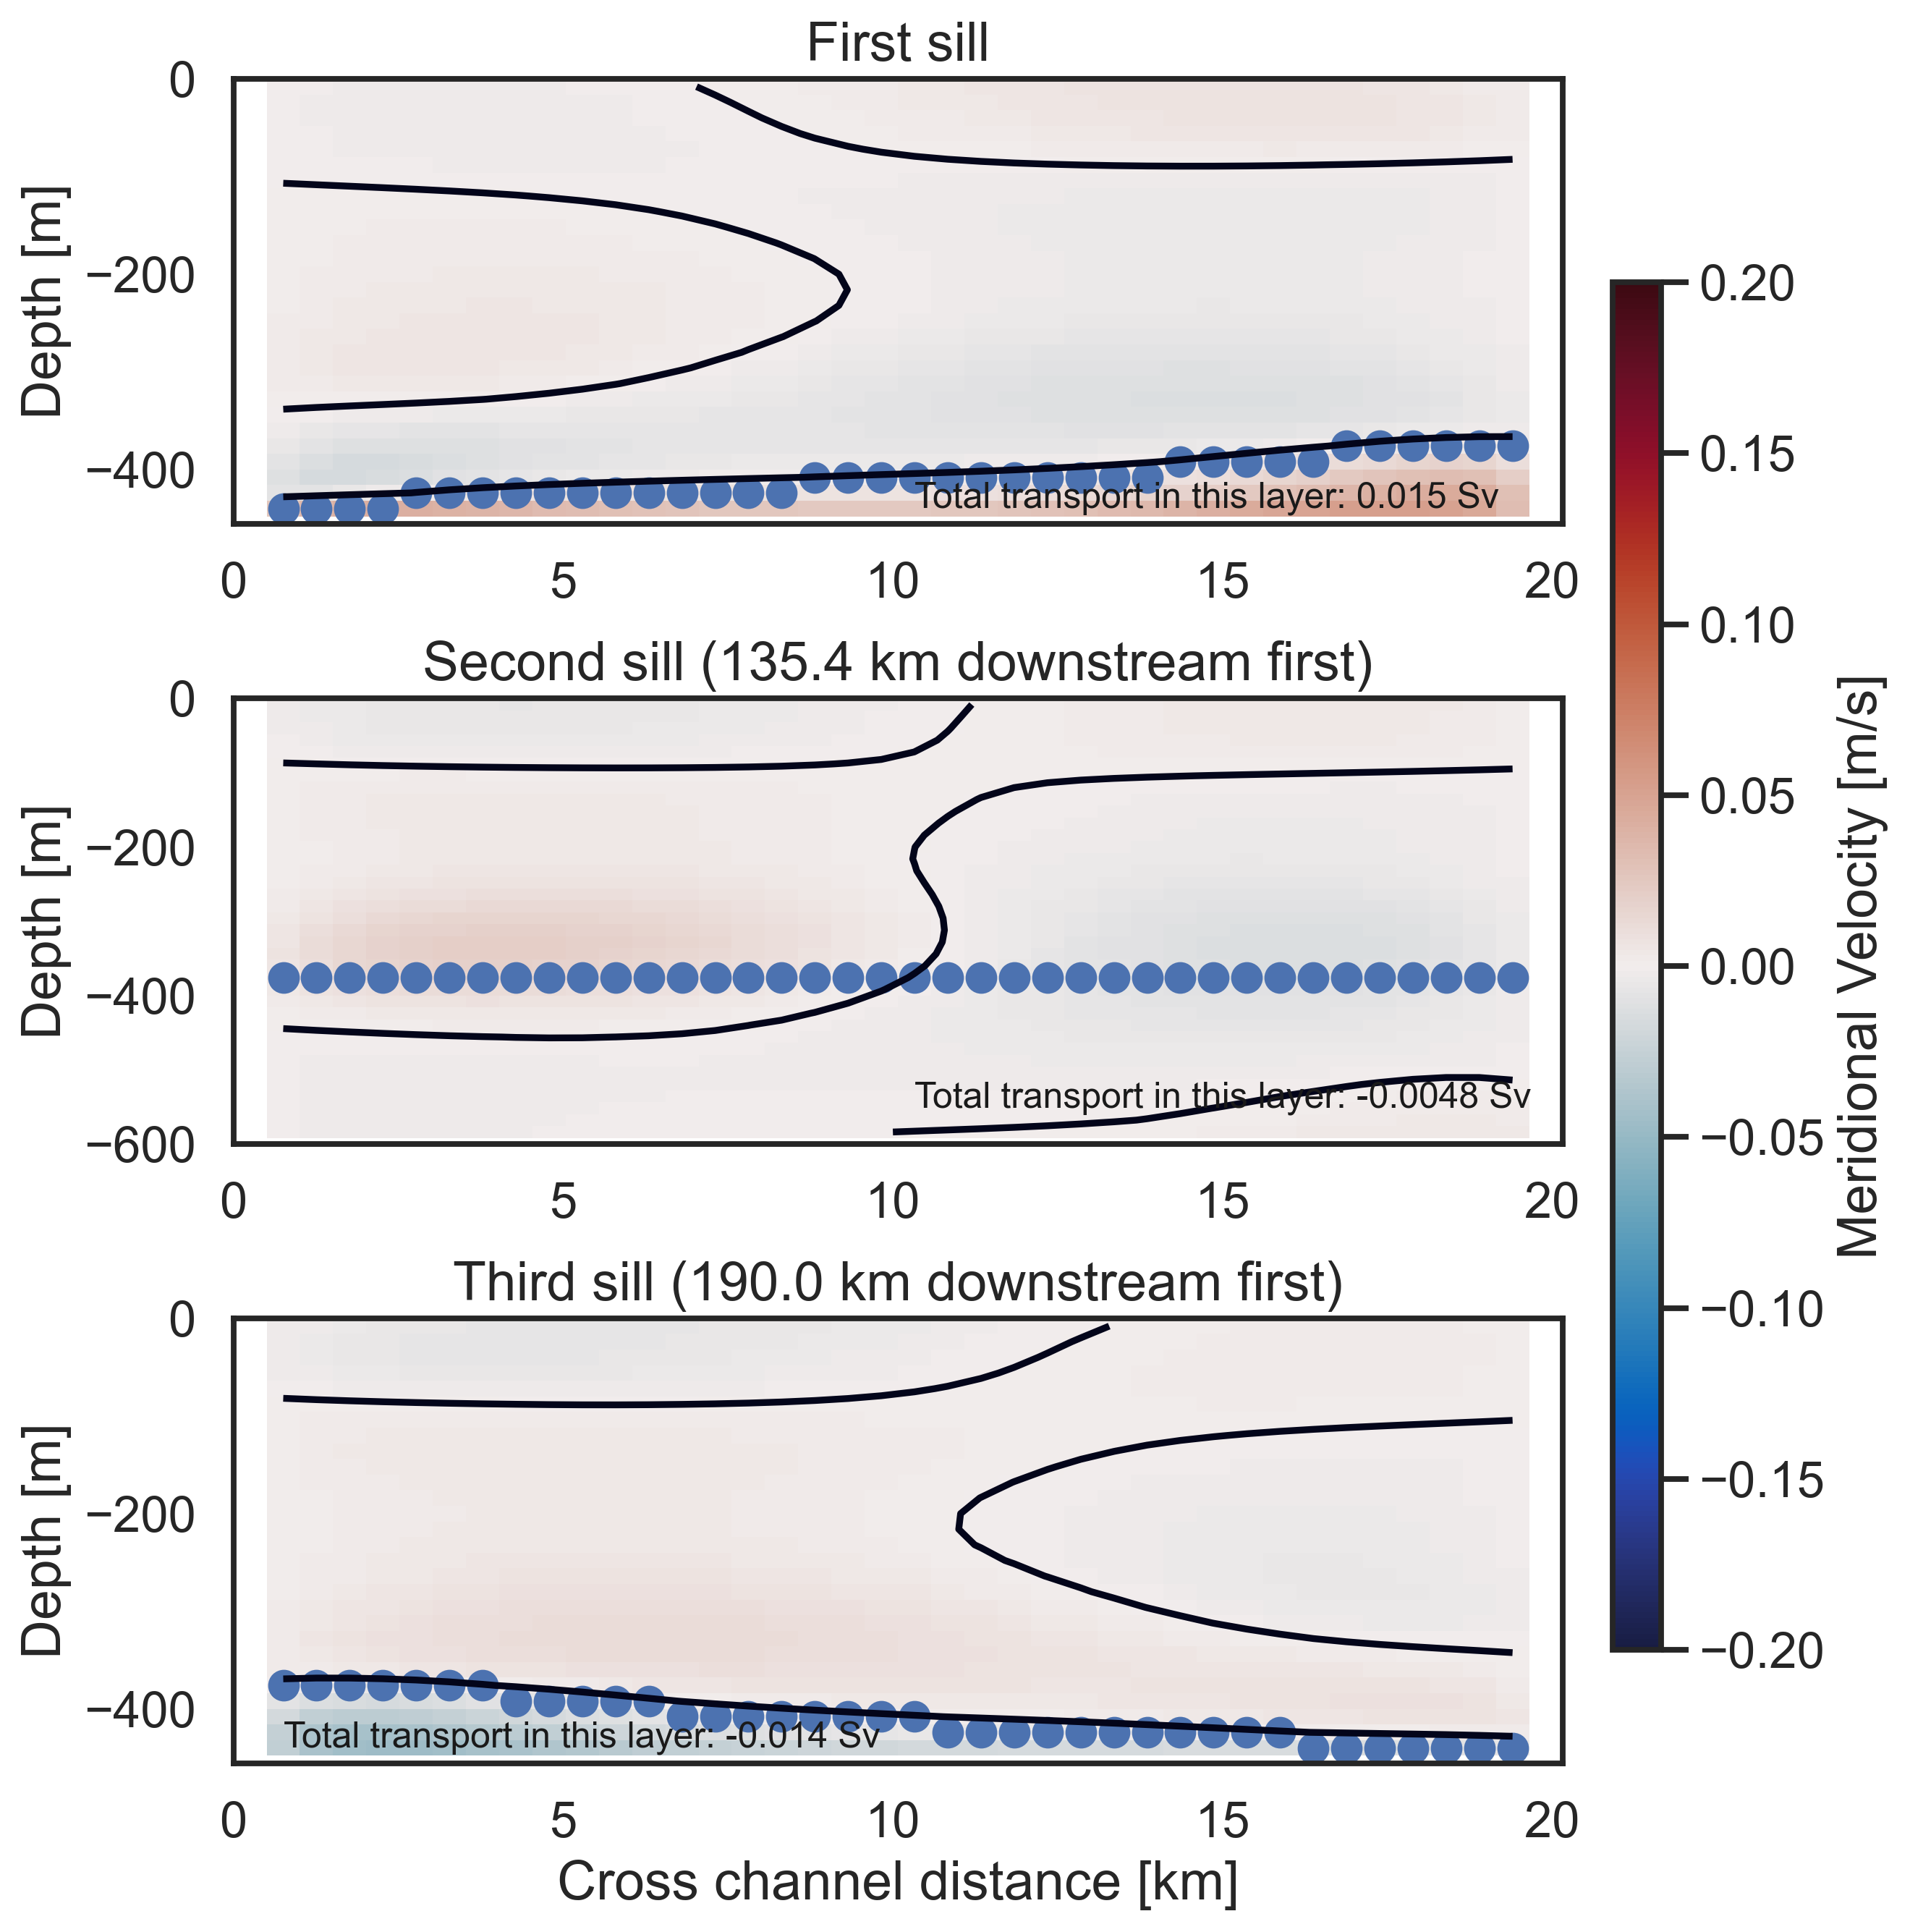

In [46]:
indy=np.arange(umbral1,umbralEnd1,1)
p=0 #np.arange(0,50,10)[0]
start=len(ds.T)-4
fig,axin=plt.subplots(3)
ax=axin[0]
cax=ax.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),:,umbral1,:],axis=0),mask=masks[:,umbral1,:]),vmin=-0.2,vmax=0.2,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[masks[:,umbral1,5]==True][0]
ax.set_ylim((ymax,0))
ax.scatter(dsG.X[1:-1]/1000,depth[0])


ax.set(ylabel='Depth [m]',title='First sill')

ax.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),:,umbral1,:],axis=0),mask=masks[:,umbral1,:]),levels=[0])

ax.text(dsG.X[20]/1000, dsG.Z[27], f'Total transport in this layer: {np.sum(transp[0]):.2g} Sv', color='k',fontsize='large')

ax=axin[1]
cax=ax.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),:,umbral2,:],axis=0),mask=masks[:,umbral2,:]),vmin=-0.2,vmax=0.2,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[masks[:,umbral2,5]==True][0]
ax.set_ylim((ymax,0))
ax.scatter(dsG.X[1:-1]/1000,depth[1])

ax.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),:,umbral2,:],axis=0),mask=masks[:,umbral2,:]),levels=[0])
ax.set(ylabel='Depth [m]',title=f'Second sill ({(dsG.Yp1[umbral2].values - dsG.Yp1[umbral1].values)/1000:.1f} km downstream first)')
ax.text(dsG.X[20]/1000, dsG.Z[34], f'Total transport in this layer: {np.sum(transp[1]):.2g} Sv', color='k',fontsize='large')


ax=axin[2]
cax=ax.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),:,umbral3,:],axis=0),mask=masks[:,umbral3,:]),vmin=-0.2,vmax=0.2,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[masks[:,umbral3,5]==True][0]
ax.set_ylim((ymax,0))
ax.scatter(dsG.X[1:-1]/1000,depth[2])

ax.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),:,umbral3,:],axis=0),mask=masks[:,umbral3,:]),levels=[0])
ax.set(ylabel='Depth [m]',xlabel='Cross channel distance [km]',title=f'Third sill ({(dsG.Yp1[umbral3].values - dsG.Yp1[umbral1].values)/1000:.1f} km downstream first)')
#ax.scatter(dsG.X[1:-1]/1000,depth[1])
ax.text(dsG.X[1]/1000, dsG.Z[27], f'Total transport in this layer: {np.sum(transp[2]):.2g} Sv', color='k',fontsize='large')

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
fig.colorbar(cax, cax=cbar_ax)
cbar_ax.set_ylabel('Meridional Velocity [m/s]')

fig.tight_layout()
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'MeridTransportPres.png', bbox_inches='tight')

In [36]:
alpha=2*1e-4
RHO=np.zeros(np.shape(ds.THETA.values))
for i in range(len(ds.T)):
    RHO[i,:,:,:]=999.8*(1-np.ma.masked_array(ds.THETA[i].values-14,mask=mask)*alpha)

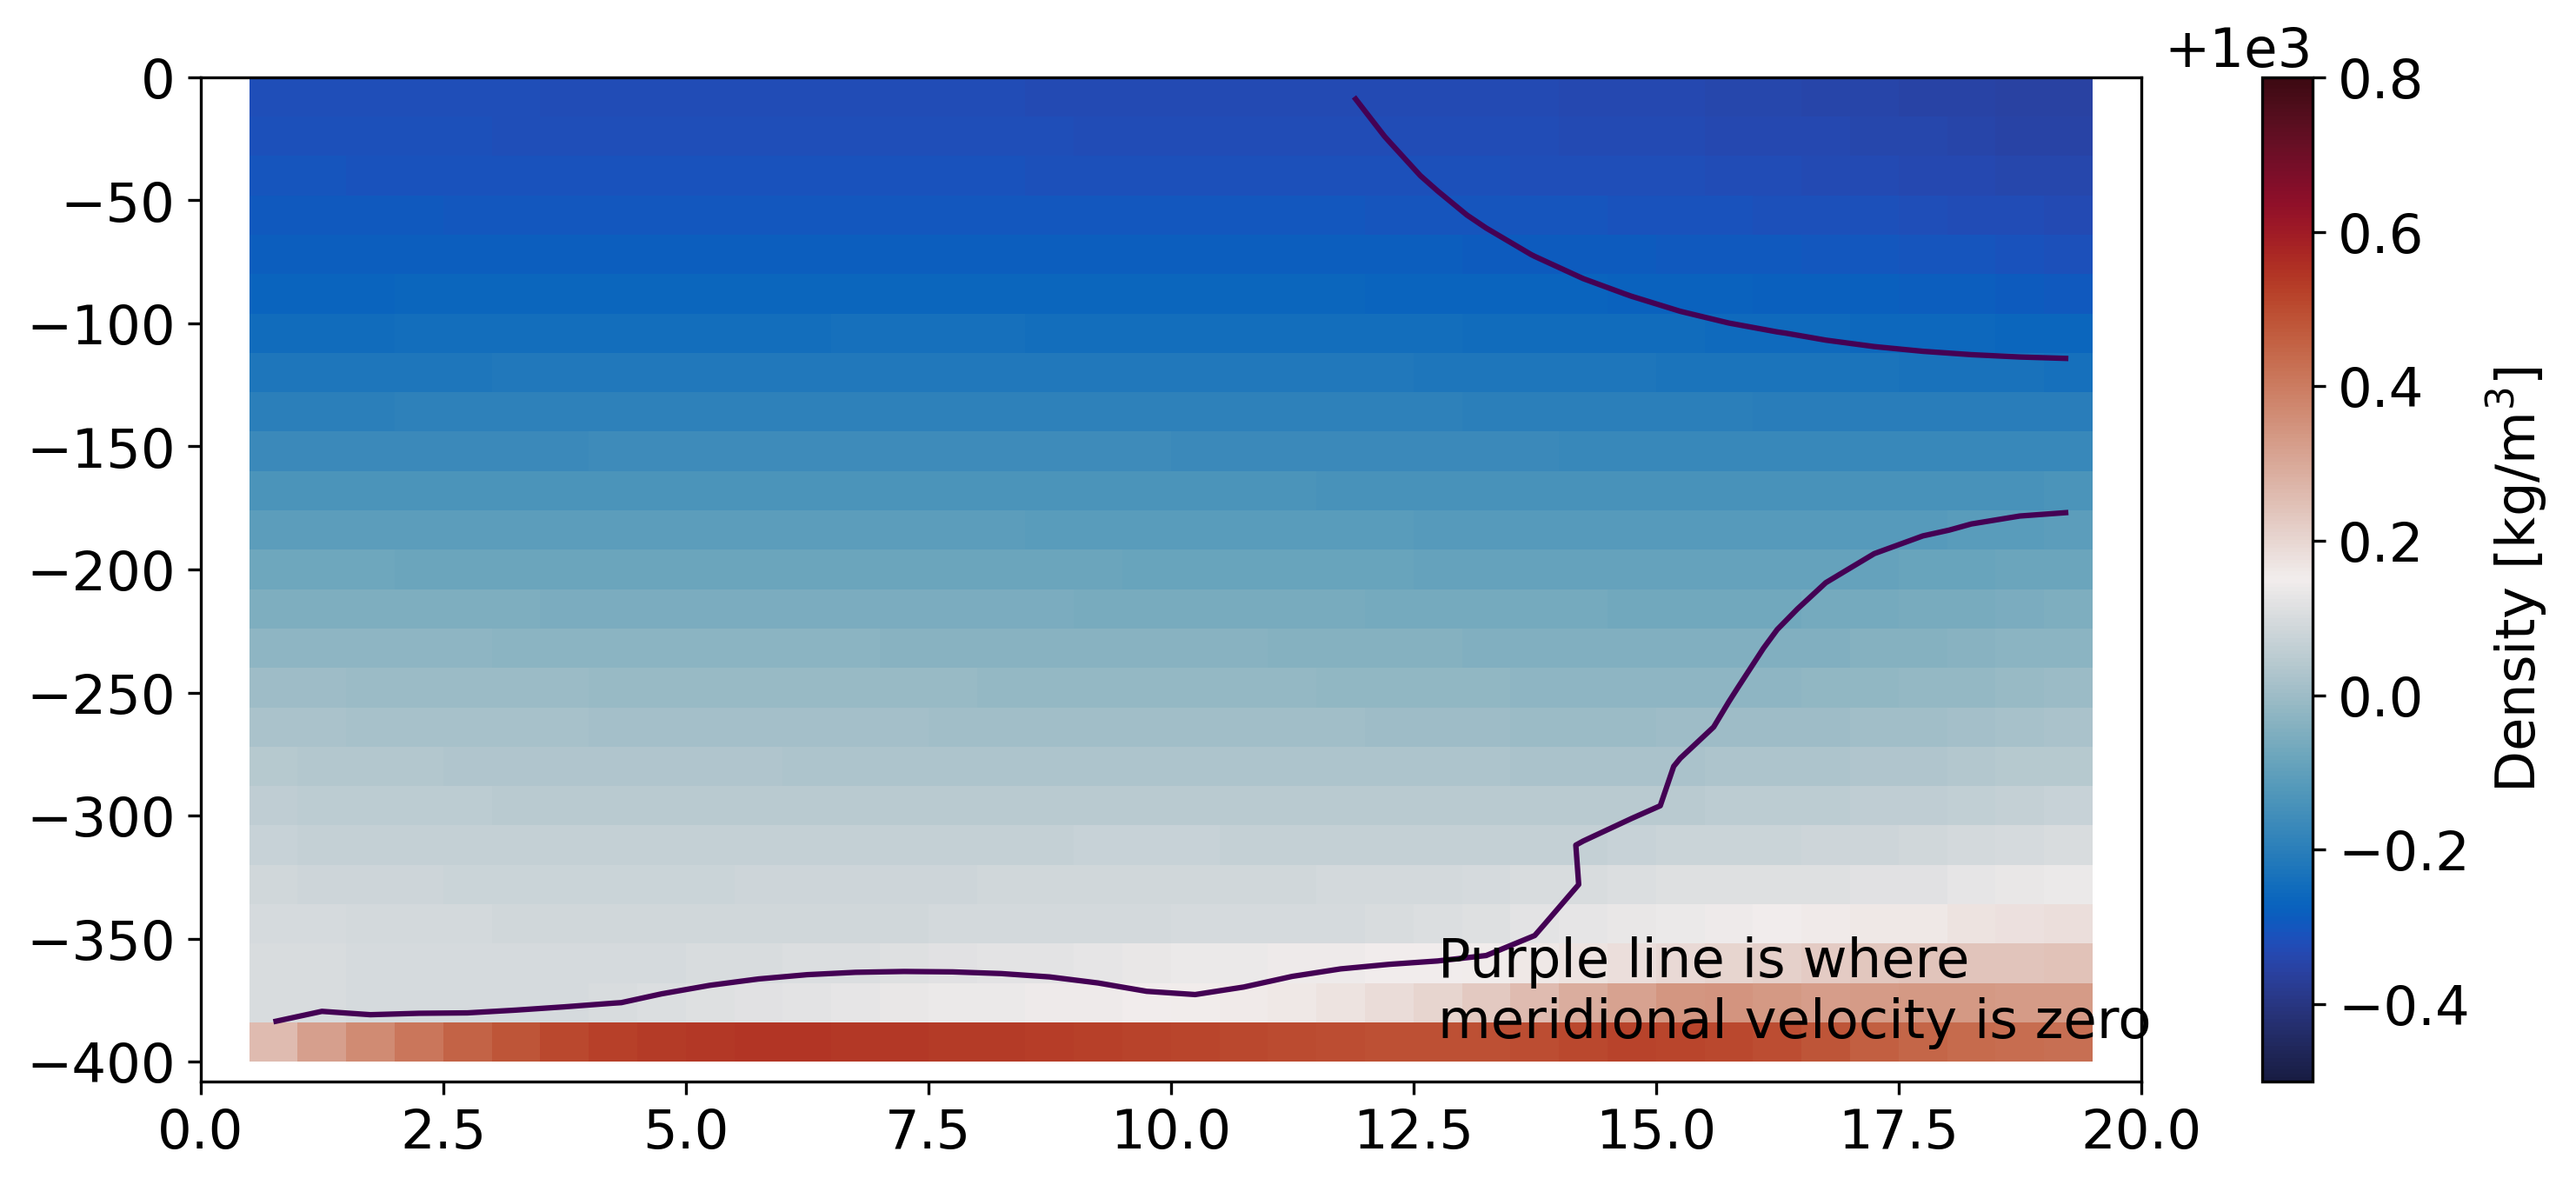

In [37]:
vmin=np.min(np.ma.masked_array(np.mean(RHO[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]))
vmax=-np.min(np.ma.masked_array(np.mean(RHO[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]))

plt.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(RHO[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]),vmin=999.5,vmax=1000.8,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[mask[:,umbral,5]==True][0]
plt.ylim((ymax,0))

cbar=plt.colorbar()
cbar.set_label('Density [kg/m$^{3}$]')
#plt.contour(dsG.X,dsG.Z[:35],ds.VVEL[-1,:35,umbral,:],levels=[0])
plt.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]),levels=[0])
plt.text(dsG.X[25]/1000, -390, f'Purple line is where\nmeridional velocity is zero', color='k',fontsize=15)
#plt.scatter(dsG.X[1:-1],dsG.Z[siz])
#for i in range(len(siz)):
#    plt.text(dsG.X[1+i]-1000, dsG.Z[siz[i]]+40, f' {((dsG.Z[siz[i]]-ymax)*2000*vel[i]*1e-6):.1g} SV', color='k',fontsize=8)

#plt.text(dsG.X[5]-2000, -200, f'Total transport\n{np.sum((dsG.Z[siz]-ymax)*2000*vel*1e-6):.1g} SV', color='k',fontsize=8)

plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'RhoTransport.png', bbox_inches='tight')

In [99]:
depindUmb=np.where(mask[:,umbral2,5])[0][0]-1

depind800=np.where(dsG.Z<-800)[0][0]

In [152]:
umbralStart2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][0]+int(ny/2)


umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]
umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)

umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)

In [94]:
def BottomConc(vel, hfac, nz,nt, ny,nx,loc):
    '''vel: Velocity field (nt,nz,ny)
       hfac: fraction of open cell at center (nz,ny)
       
       
       RETURNS:
       
       BotVel = velocity near bottom (nt,ny)'''
    
    BotVel = np.empty((nt,ny,nx))
    BottomInd = np.argmax(hfac[::-1,:,5]>0.0,axis=0) # start looking for first no-land cell from the bottom up.
    BottomInd = (np.ones(np.shape(BottomInd))*nz - BottomInd)-loc # Get index of unreversed z axis
    
    for j in range(nt):
        for i in range(ny): 
            for k in range(nx): 
                BotVel[j,i,k] = vel[j,int(BottomInd[i]),i,k] 
                
    
    return (BotVel,BottomInd.astype(int))


In [95]:
nz=len(dsG.Z)
ny=len(dsG.Y)
nt=len(ds.T)
nx=len(dsG.X)

tempOut,BottomInd=BottomConc(ds.WRHOMASS[:,:,:,:],hFacC[:,:,:].values , nz, nt, ny,nx,1)
vvelOut,BottomInd=BottomConc(ds.VVEL[:,:,:,:],hFacS[:,:,:].values , nz, nt, ny+1,nx,1)
uvelOut,BottomInd=BottomConc(ds.UVEL[:,:,:,:],hFacW[:,:,:].values , nz, nt, ny,nx+1,1)

In [96]:
params = {'font.size': 15,
          'figure.figsize': (10, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

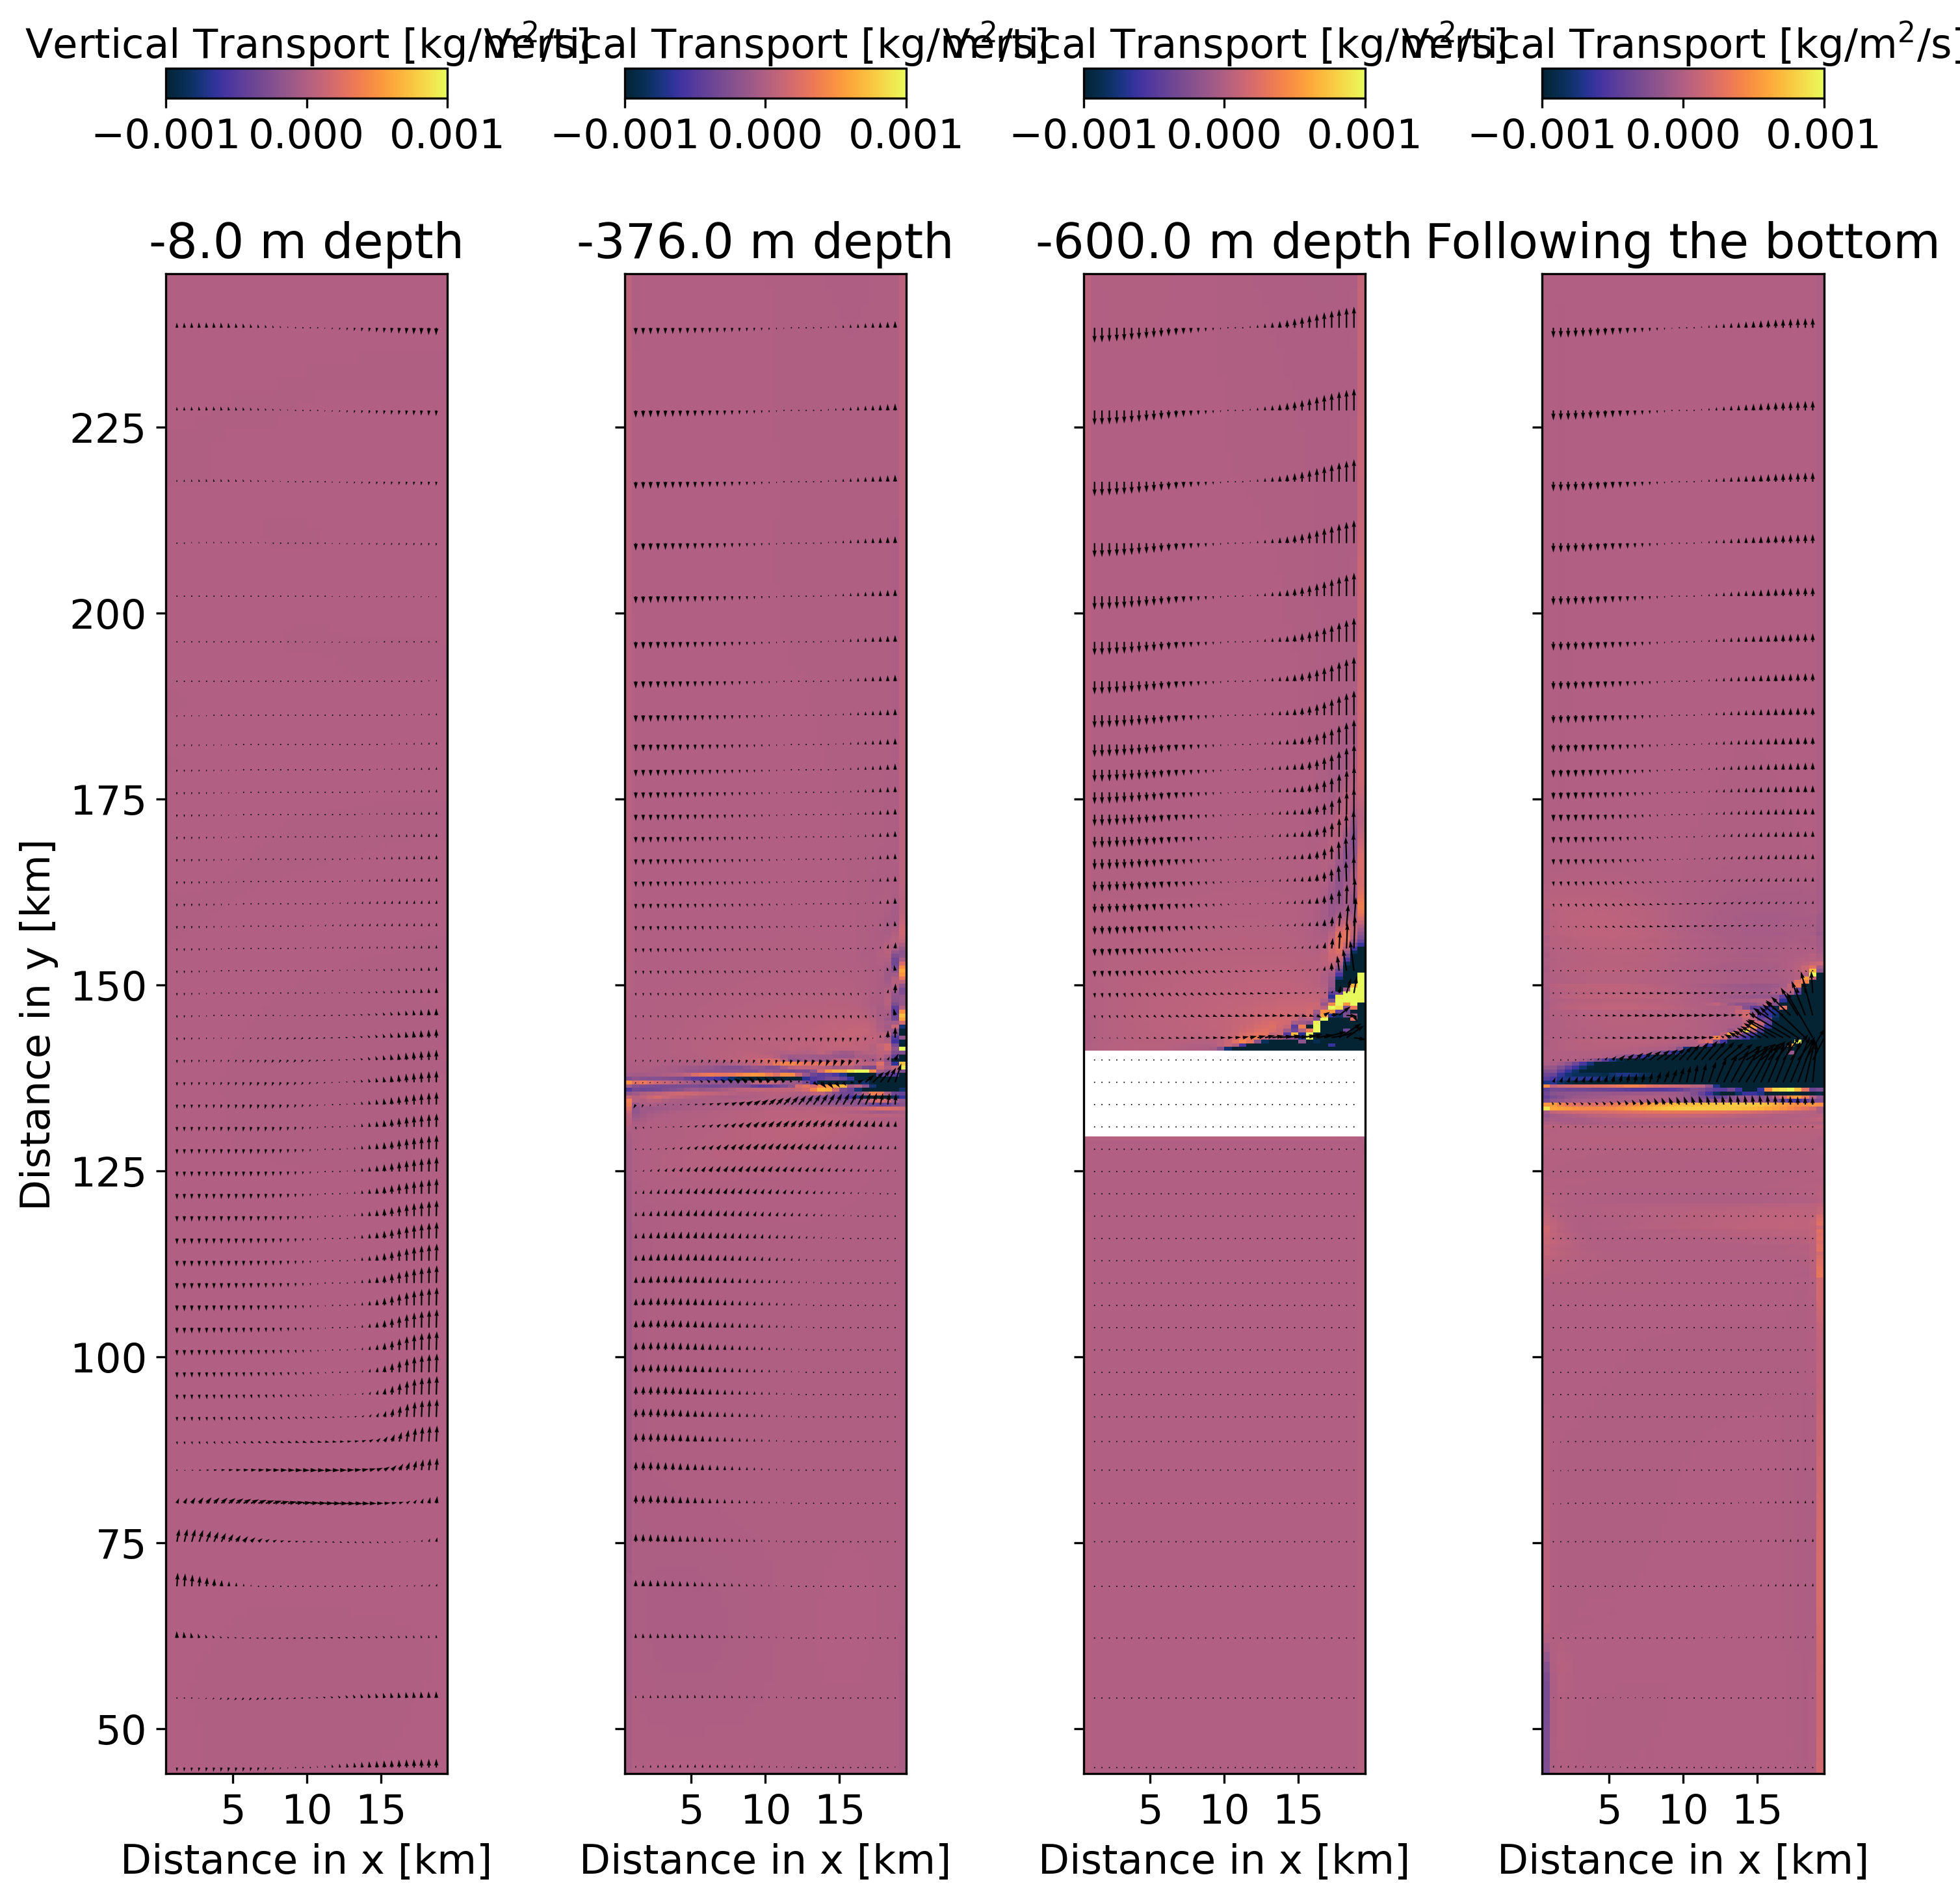

In [97]:
t=0
space=6
spacex=1
dep=[0,23,37]
VARS=list(ds.keys())[:]
widths = 0.005# np.linspace(0, 2, dsG.X[OBx:OBendx].values.size)

#for variable in VARS:

variable=VARS[2]

varin=ds.WRHOMASS
title= 'Vertical Transport [kg/m$^2$/s]'

Yin=dsG.Y
Xin=dsG.X[OBx:OBendx]

cmapi=cmocean.cm.thermal

fig,ax=plt.subplots(1,4)


tin=-1


axin=ax[0]
vmin=-0.001 #np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
vmax=0.001 #-np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
axin.set(xlabel='Distance in x [km]',ylabel='Distance in y [km]')

timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.ma.masked_array(np.mean(varin[start:end,dep[0],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[0],OB:OBend,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[0]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(ds.VVEL[start:end,dep[0],OB:OBend,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(ds.UVEL[start:end,dep[0],OB:OBend,:].values,axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[1]

#vmin=11 #np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
#vmax=13 #-np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.ma.masked_array(np.mean(varin[start:end,dep[1],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[1],OB:OBend,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[1]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(ds.VVEL[start:end,dep[1],OB:OBend,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(ds.UVEL[start:end,dep[1],OB:OBend,:].values,axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[2]

#vmin=11 #np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
#vmax=12 # -np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.ma.masked_array(np.mean(varin[start:end,dep[2],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[2],OB:OBend,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[2]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(ds.VVEL[start:end,dep[2],OB:OBend,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(ds.UVEL[start:end,dep[2],OB:OBend,:].values,axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[3]

#vmin= 10#np.min(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
#vmax= 12#np.max(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')

indmean=23
timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.mean(tempOut[start:end,OB:OBend,OBx:OBendx],axis=0),vmin=vmin,vmax=vmax,cmap=cmapi)


gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(vvelOut[start:end,OB:OBend,:],axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(uvelOut[start:end,OB:OBend,:],axis=0))
U=interpU((gridY,gridX))
gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:],width=widths)

axin.set(title=f'Following the bottom')


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

fig.tight_layout()

fig.patch.set_alpha(0.0)
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'WtranspDifDepths.png', bbox_inches='tight')